In [1]:
import numpy as np
import timeit
import viscid
import os
from scipy.special import iv

argsdict=viscid.argsdict
from scipy.linalg import eig
from scipy.interpolate import interp1d
from scipy.optimize import minimize_scalar
from scipy.signal import find_peaks

import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation

import json
colors = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",
    "#bcbd22",
    "#17becf",
]

start0=timeit.default_timer()

s=5
s2=0.2
admax=5.0
dfreq=20.0
maxfreq=60
minfreq=15

eta=1E-6
argsdict['dim']=2
argsdict['Nx']=3
argsdict['Ny']=3
argsdict['Nt']=3
argsdict['k1x']=np.pi*s
argsdict['k1y']=0
argsdict['k2x']=-np.pi*s/2
argsdict['k2y']=3**0.5*s/2*np.pi
argsdict['h0']=1.0*s2
argsdict['As']=0.75*s2


num1=52
kxs1=np.arange(1,num1+1)/num1*argsdict['k1x']/2
kys1=np.arange(1,num1+1)/num1*0
num2=30
kxs2=argsdict['k1x']/2+np.arange(1,num2+1)/num2*((2*argsdict['k1x'] + argsdict['k2x'])/3 - argsdict['k1x']/2)
kys2=argsdict['k1y']/2+np.arange(1,num2+1)/num2*((2*argsdict['k1y'] + argsdict['k2y'])/3 - argsdict['k1y']/2)
num3=60
kxs3=np.arange(1,num3)/num3*((2*argsdict['k1x'] + argsdict['k2x'])/3)
kys3=np.arange(1,num3)/num3*((2*argsdict['k1y'] + argsdict['k2y'])/3)
ks=np.concatenate([np.transpose([kxs1[-20:-1:2],kys1[-20:-1:2]]),np.transpose([kxs2[::2],kys2[::2]]),np.transpose([kxs3[-2:-16:-2],kys3[-2:-16:-2]])])

argsdict['rho']=1.0
argsdict['sigma']=20
argsdict['mu']=0.2

Fluid depth in cm

In [2]:
argsdict['h0']

0.2

Substrate amplitude in cm

In [3]:
argsdict['As']

0.15000000000000002

Substrate wavelength in cm

In [4]:
2*np.pi/argsdict['k1x']

0.4

### Dispersion relations and band gap for the inviscid problem

In [5]:
start=timeit.default_timer()

argsdict['As']=0.0
evalssweep1=[]
revecssweep1=[]
levecssweep1=[]
for i in range(num1):
    argsdict['kx']=kxs1[i]
    argsdict['ky']=kys1[i]
    F,G=viscid.inviscid_mat_undriven(argsdict)
    evals,revecs,levecs=eig(F,G,right=True,left=True)
    evalssweep1=evalssweep1+[evals]
    revecssweep1=revecssweep1+[revecs]
    levecssweep1=levecssweep1+[levecs]
stop=timeit.default_timer()
print(stop-start)

start=timeit.default_timer()
evalssweep2=[]
revecssweep2=[]
levecssweep2=[]
for i in range(num2-1):
    argsdict['kx']=kxs2[i]
    argsdict['ky']=kys2[i]
    F,G=viscid.inviscid_mat_undriven(argsdict)
    evals,revecs,levecs=eig(F,G,right=True,left=True)
    evalssweep2=evalssweep2+[evals]
    revecssweep2=revecssweep2+[revecs]
    levecssweep2=levecssweep2+[levecs]
    
stop=timeit.default_timer()
print(stop-start)

start=timeit.default_timer()
evalssweep3=[]
revecssweep3=[]
levecssweep3=[]
for i in range(num3-1):
    argsdict['kx']=kxs3[i]
    argsdict['ky']=kys3[i]
    F,G=viscid.inviscid_mat_undriven(argsdict)
    evals,revecs,levecs=eig(F,G,right=True,left=True)
    evalssweep3=evalssweep3+[evals]
    revecssweep3=revecssweep3+[revecs]
    levecssweep3=levecssweep3+[levecs]

stop=timeit.default_timer()
print(stop-start)

vals1=np.sort(np.real((np.array(evalssweep1))**0.5/(2*np.pi)),axis=1)
vals2=np.sort(np.real((np.array(evalssweep2))**0.5/(2*np.pi)),axis=1)
vals3=np.flip(np.sort(np.real((np.array(evalssweep3))**0.5/(2*np.pi)),axis=1),axis=0)

argsdict['As']=0.75*s2
evalssweep12=[]
revecssweep12=[]
levecssweep12=[]
for i in range(len(kxs1)):
    argsdict['kx']=kxs1[i]
    argsdict['ky']=kys1[i]
    F,G=viscid.inviscid_mat_undriven(argsdict)
    evals,revecs,levecs=eig(F,G,right=True,left=True)
    evalssweep12=evalssweep12+[evals]
    revecssweep12=revecssweep12+[revecs]
    levecssweep12=levecssweep12+[np.conjugate(levecs)]
    
stop=timeit.default_timer()
print(stop-start)

start=timeit.default_timer()
evalssweep22=[]
revecssweep22=[]
levecssweep22=[]
for i in range(len(kxs2)):
    argsdict['kx']=kxs2[i]
    argsdict['ky']=kys2[i]
    F,G=viscid.inviscid_mat_undriven(argsdict)
    evals,revecs,levecs=eig(F,G,right=True,left=True)
    evalssweep22=evalssweep22+[evals]
    revecssweep22=revecssweep22+[revecs]
    levecssweep22=levecssweep22+[np.conjugate(levecs)]
    
stop=timeit.default_timer()
print(stop-start)

start=timeit.default_timer()
evalssweep32=[]
revecssweep32=[]
levecssweep32=[]
for i in range(len(kxs3)):
    argsdict['kx']=kxs3[i]
    argsdict['ky']=kys3[i]
    F,G=viscid.inviscid_mat_undriven(argsdict)
    evals,revecs,levecs=eig(F,G,right=True,left=True)
    evalssweep32=evalssweep32+[evals]
    revecssweep32=revecssweep32+[revecs]
    levecssweep32=levecssweep32+[np.conjugate(levecs)]

stop=timeit.default_timer()
print(stop-start)

vals12=np.sort(np.real((np.array(evalssweep12))**0.5/(2*np.pi)),axis=1)
vals22=np.sort(np.real((np.array(evalssweep22))**0.5/(2*np.pi)),axis=1)
vals32=np.flip(np.sort(np.real((np.array(evalssweep32))**0.5/(2*np.pi)),axis=1),axis=0)


0.15662845503538847
0.04928077617660165
0.09950802521780133
0.33700061589479446
0.1303657959215343
0.22366891475394368


47.34312040782576 40.195297065149234
[40.19529707 40.19529707]
45.52608001811899 39.52455937048163
[37.48932701 39.52455937]


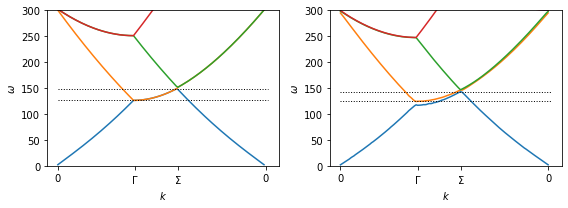

In [6]:
plt.subplots(1,2,figsize=(8,3))

plt.subplot(1,2,1)

plt.ylim(0,300)
plt.plot(np.concatenate([vals1,vals2,vals3])*2*np.pi)
plt.plot([0,num1+num2+num3],[np.max(np.concatenate([vals1,vals2,vals3])[:,0]*2*np.pi),np.max(np.concatenate([vals1,vals2,vals3])[:,0]*2*np.pi)],ls=':',lw=1,c='black')
plt.plot([0,num1+num2+num3],[np.min(np.concatenate([vals1,vals2,vals3])[:,1]*2*np.pi),np.min(np.concatenate([vals1,vals2,vals3])[:,1]*2*np.pi)],ls=':',lw=1,c='black')

print(2*np.max(np.concatenate([vals1,vals2,vals3])[:,0]),2*np.min(np.concatenate([vals1,vals2,vals3])[:,1]))
print(vals1[-1][:2]*2)
plt.xticks([0,num1,num1+num2-1,num1+num2+num3-2],['0','$\Gamma$','$\Sigma$','0'])
plt.xlabel('$k$')
plt.ylabel('$\omega$')

plt.subplot(1,2,2)
plt.ylim(0,300)
plt.plot(np.concatenate([vals12,vals22,vals32])*2*np.pi)
plt.plot([0,num1+num2+num3],[np.max(np.concatenate([vals12,vals22,vals32])[:,0]*2*np.pi),np.max(np.concatenate([vals12,vals22,vals32])[:,0]*2*np.pi)],ls=':',lw=1,c='black')
plt.plot([0,num1+num2+num3],[np.min(np.concatenate([vals12,vals22,vals32])[:,1]*2*np.pi),np.min(np.concatenate([vals12,vals22,vals32])[:,1]*2*np.pi)],ls=':',lw=1,c='black')

print(2*np.max(np.concatenate([vals12,vals22,vals32])[:,0]),2*np.min(np.concatenate([vals12,vals22,vals32])[:,1]))
print(vals12[-1][:2]*2)
plt.xticks([0,num1,num1+num2-1,num1+num2+num3-2],['0','$\Gamma$','$\Sigma$','0'])
plt.xlabel('$k$')
plt.ylabel('$\omega$')


plt.tight_layout()
plt.savefig('plots/dispersion_experiment.pdf')
plt.show()

47.34312040782576 40.195297065149234
[40.19529707 40.19529707]
45.52608001811899 39.52455937048163
[37.48932701 39.52455937]


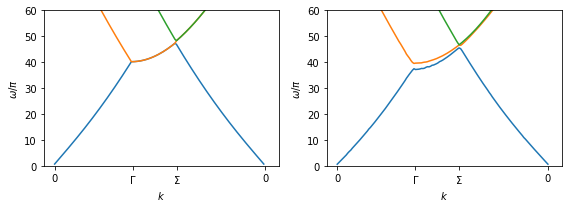

In [24]:
plt.subplots(1,2,figsize=(8,3))

plt.subplot(1,2,1)

plt.ylim(0,60)
plt.plot(np.concatenate([vals1,vals2,vals3])*2)
plt.plot([0,num1+num2+num3],[np.max(np.concatenate([vals1,vals2,vals3])[:,0]*2*np.pi),np.max(np.concatenate([vals1,vals2,vals3])[:,0]*2*np.pi)],ls=':',lw=1,c='black')
plt.plot([0,num1+num2+num3],[np.min(np.concatenate([vals1,vals2,vals3])[:,1]*2*np.pi),np.min(np.concatenate([vals1,vals2,vals3])[:,1]*2*np.pi)],ls=':',lw=1,c='black')

print(2*np.max(np.concatenate([vals1,vals2,vals3])[:,0]),2*np.min(np.concatenate([vals1,vals2,vals3])[:,1]))
print(vals1[-1][:2]*2)
plt.xticks([0,num1,num1+num2-1,num1+num2+num3-2],['0','$\Gamma$','$\Sigma$','0'])
plt.xlabel('$k$')
plt.ylabel('$\omega/\pi$')

plt.subplot(1,2,2)
plt.ylim(0,60)
plt.plot(np.concatenate([vals12,vals22,vals32])*2)
plt.plot([0,num1+num2+num3],[np.max(np.concatenate([vals12,vals22,vals32])[:,0]*2*np.pi),np.max(np.concatenate([vals12,vals22,vals32])[:,0]*2*np.pi)],ls=':',lw=1,c='black')
plt.plot([0,num1+num2+num3],[np.min(np.concatenate([vals12,vals22,vals32])[:,1]*2*np.pi),np.min(np.concatenate([vals12,vals22,vals32])[:,1]*2*np.pi)],ls=':',lw=1,c='black')

print(2*np.max(np.concatenate([vals12,vals22,vals32])[:,0]),2*np.min(np.concatenate([vals12,vals22,vals32])[:,1]))
print(vals12[-1][:2]*2)
plt.xticks([0,num1,num1+num2-1,num1+num2+num3-2],['0','$\Gamma$','$\Sigma$','0'])
plt.xlabel('$k$')
plt.ylabel('$\omega/\pi$')


plt.tight_layout()
plt.savefig('plots/dispersion_experiment.pdf')
plt.show()

### Viscid instability boundary for As=0.15

In [11]:
argsdict['ad']=0
argsdict['kx']=ks[0][0]
argsdict['ky']=ks[0][1]
argsdict['verbose']=1
argsdict['dsmin']=1E-4


def mat0(omega,argsdict):
        E,F=viscid.viscid_mat2d(omega,argsdict)
        shape=E.shape
        E_shaped=E.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))
        F_shaped=F.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))

        return (np.tensordot(E_shaped,argsdict['preconditioner'],axes=argsdict['precondition_axes'])-argsdict['ad']*np.tensordot(F_shaped,argsdict['preconditioner'],axes=argsdict['precondition_axes'])).transpose(argsdict['precondition_order']).reshape(shape).T
def mat3(omega,argsdict):
        E,F=viscid.viscid_mat2d(omega,argsdict)
        shape=E.shape
        E_shaped=E.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))
        F_shaped=F.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))

        return (-np.tensordot(F_shaped,argsdict['preconditioner'],axes=argsdict['precondition_axes'])).transpose(argsdict['precondition_order']).reshape(shape).T

def mat(ad,argsdict):
    E,F=viscid.viscid_mat2d(2*np.pi*argsdict['freq']/2,argsdict)
    shape=E.shape
    E_shaped=E.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))
    F_shaped=F.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))

    return (np.tensordot(E_shaped,argsdict['preconditioner'],axes=argsdict['precondition_axes'])-ad*np.tensordot(F_shaped,argsdict['preconditioner'],axes=argsdict['precondition_axes'])).transpose(argsdict['precondition_order']).reshape(shape).T
def mat2(ad,argsdict):
    E,F=viscid.viscid_mat2d(2*np.pi*argsdict['freq']/2,argsdict)
    shape=E.shape
    E_shaped=E.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))
    F_shaped=F.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))

    return (-np.tensordot(F_shaped,argsdict['preconditioner'],axes=argsdict['precondition_axes'])).transpose(argsdict['precondition_order']).reshape(shape).T

Find the starting critical eigenvalues and eigenvectors by continuing the driving amplitude and finding the critical value at fixed frequency and wavenumber

In [12]:
argsdict['kx']=ks[0][0]
argsdict['ky']=ks[0][1]
F,G=viscid.inviscid_mat_undriven(argsdict)
evals,revecs,levecs=eig(F,G,right=True,left=True)
order=np.argsort(np.real(evals))
freq0s=0.9*np.real(evals[order[:2]]**0.5/(2*np.pi/2)) #reduce the frequency a bit relative to inviscid case
print(freq0s)

argsdict['verbose']=3
argsdict['lambdamax']=np.inf
ds=1E-1
dsmax=1E1
argsdict['itmax']=10
argsdict['ds']=ds
argsdict['dsmax']=dsmax
argsdict['dsmin']=1E-4
argsdict['epsl']=1E-2
argsdict['epsu']=1E-2
argsdict['epstp']=1E0
argsdict['thmu']=1E1
argsdict['thl']=1E-1
argsdict['thu']=1E-4

ads01=[]
ads02=[]
ads03=[]
vs01=[]
vs02=[]
vs03=[]
ws01=[]
ws02=[]
ws03=[]
omegas01=[]
omegas02=[]
omegas03=[]
dirs01=[]

load=True
overwrite=True

start=timeit.default_timer()
for j in range(2):
    if not os.path.exists('data/experiment/%iads01.npy'%(j)) or not load:
        omega=evals[order[j]]**0.5+1j*0
        E,F=viscid.viscid_mat2d(omega,argsdict)

        v=np.zeros((3,(2*argsdict['Nt']+1),(2*argsdict['Nx']+1),(2*argsdict['Ny']+1)),np.complex128)
        w=np.zeros((3,(2*argsdict['Nt']+1),(2*argsdict['Nx']+1),(2*argsdict['Ny']+1)),np.complex128)
        v[2,argsdict['Nt']]=revecs[:,order[j]].reshape((2*argsdict['Nx']+1,2*argsdict['Ny']+1))
        w[2,argsdict['Nt']]=levecs[:,order[j]].reshape((2*argsdict['Nx']+1,2*argsdict['Ny']+1))
        v=v.ravel()
        w=w.ravel()

        freq0=freq0s[j]
        omega=evals[order[j]]**0.5+1j*0
        argsdict['freq']=freq0
        argsdict['ad']=0

        lps,ls,mps,ms,nps,ns=viscid.makeindices(argsdict)
        kappax = (argsdict['kx'] + argsdict['k1x']*ms + argsdict['k2x']*ns)
        kappay = (argsdict['ky'] + argsdict['k1y']*ms + argsdict['k2y']*ns)
        kappa = (kappax**2+kappay**2)**0.5
        kappapx = (argsdict['kx'] + argsdict['k1x']*mps + argsdict['k2x']*nps)
        kappapy = (argsdict['ky'] + argsdict['k1y']*mps + argsdict['k2y']*nps)
        S = (- np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))
        C = (np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))

        #right preconditioner
        shape_flat=((2*argsdict['Nx']+1)*(2*argsdict['Ny']+1),(2*argsdict['Nx']+1)*(2*argsdict['Ny']+1))
        shape2=((2*argsdict['Nx']+1),(2*argsdict['Ny']+1),(2*argsdict['Nx']+1),(2*argsdict['Ny']+1))
        A2=argsdict['g']*(argsdict['rho']**2*(kappax*kappapx+kappay*kappapy)/kappa*S)
        argsdict['preconditioner']=np.linalg.inv(A2.reshape(shape_flat)).reshape(shape2)

        argsdict['precondition_axes']=((6,7),(0,1))
        argsdict['precondition_order']=(0,1,2,3,4,5,6,7)


        #starting frequency and driving
        omegas,vs,ws=viscid.rayleigh_mat(omega,v,np.conjugate(w),mat0,argsdict)
        omega0=omegas[-1]
        v0=vs[-1]
        w0=ws[-1]
        print(freq0,omegas[-1]/np.pi)
        argsdict['par']='ad'
        argsdict['pari']=0
        argsdict['parf']=admax
        argsdict['ds']=ds/10
        argsdict['dsmax']=dsmax
        omegas,vs,ws,pars,dirs,dss=viscid.pseudocont(omega0,v0,w0,mat0,argsdict,mat3=mat3, real=1)
        omegas01=omegas01+[omegas]
        vs01=vs01+[vs]
        ws01=ws01+[ws]
        ads01=ads01+[pars]
        dirs01=dirs01+[dirs]
        plt.plot(ads01[j],np.real(omegas01[j])/(2*np.pi*freq0s[j]),c=colors[0], marker='o', ms=5)
        plt.show()
        
        ind=np.argmax(pars)
        fomega=interp1d(np.arange(len(omegas)),omegas,kind='cubic')
        fv=interp1d(np.arange(len(omegas)),np.array(vs).T,kind='cubic')
        fw=interp1d(np.arange(len(omegas)),np.array(ws).T,kind='cubic')
        fpar=interp1d(np.arange(len(omegas)),pars,kind='cubic')
        fdir=interp1d(np.arange(len(omegas)),np.array(dirs).T,kind='cubic')

        if ind<len(pars)-3:
            if pars[ind-2]<pars[ind] and pars[ind+2]<pars[ind]:
                find=minimize_scalar(lambda x: -fpar(x),bracket=(ind-1,ind+1)).x
            else:
                find=minimize_scalar(lambda x: fpar(x),bracket=(ind-1,ind+1)).x
        else:
            find=ind
            
        omega0=complex(fomega(find))
        v0=fv(find)
        w0=fw(find)
        dir0=fdir(find)
        s=3*(2*argsdict['Nt']+1)*(2*argsdict['Nx']+1)*(2*argsdict['Ny']+1)
        newdir=np.zeros(dir0.shape)
        newdir[:s]=dir0[s:2*s]
        newdir[s:2*s]=-dir0[:s]
        newdir[2*s]=dir0[2*s+1]
        newdir[2*s+1]=-dir0[2*s]
        newdir[2*s+2]=2*dir0[2*s+2]
        dir0=newdir
        argsdict['ad']=fpar(find)
        print(ind,argsdict['ad'],omega0)
        argsdict['ds']=ds
        argsdict['dsmax']=dsmax
        omegas,vs,ws,pars,dirs,dss=viscid.pseudocont(omega0,v0,w0,mat0,argsdict,mat3=mat3,dir=dir0,real=-1)
        omegas02=omegas02+[omegas]
        vs02=vs02+[vs]
        ws02=ws02+[ws]
        ads02=ads02+[pars]
        argsdict['ds']=-ds*10
        argsdict['ad']=fpar(find)
        omegas,vs,ws,pars,dirs,dss=viscid.pseudocont(omega0,v0,w0,mat0,argsdict,mat3=mat3,dir=dir0,real=-1)
        argsdict['ds']=-argsdict['ds']
        omegas03=omegas03+[omegas]
        vs03=vs03+[vs]
        ws03=ws03+[ws]
        ads03=ads03+[pars]

        if overwrite:
            np.save('data/experiment/%iomegas01.npy'%(j),omegas01[j])
            np.save('data/experiment/%iads01.npy'%(j),ads01[j])
            np.save('data/experiment/%ivs01.npy'%(j),vs01[j])
            np.save('data/experiment/%iws01.npy'%(j),ws01[j])

            np.save('data/experiment/%iomegas02.npy'%(j),omegas02[j])
            np.save('data/experiment/%iads02.npy'%(j),ads02[j])
            np.save('data/experiment/%ivs02.npy'%(j),vs02[j])
            np.save('data/experiment/%iws02.npy'%(j),ws02[j])

            np.save('data/experiment/%iomegas03.npy'%(j),omegas03[j])
            np.save('data/experiment/%iads03.npy'%(j),ads03[j])
            np.save('data/experiment/%ivs03.npy'%(j),vs03[j])
            np.save('data/experiment/%iws03.npy'%(j),ws03[j])
    else:
        omegas01=omegas01+[np.load('data/experiment/%iomegas01.npy'%(j))]
        ads01=ads01+[np.load('data/experiment/%iads01.npy'%(j))]
        vs01=vs01+[np.load('data/experiment/%ivs01.npy'%(j))]
        ws01=ws01+[np.load('data/experiment/%iws01.npy'%(j))]

        omegas02=omegas02+[np.load('data/experiment/%iomegas02.npy'%(j))]
        ads02=ads02+[np.load('data/experiment/%iads02.npy'%(j))]
        vs02=vs02+[np.load('data/experiment/%ivs02.npy'%(j))]
        ws02=ws02+[np.load('data/experiment/%iws02.npy'%(j))]

        omegas03=omegas03+[np.load('data/experiment/%iomegas03.npy'%(j))]
        ads03=ads03+[np.load('data/experiment/%iads03.npy'%(j))]
        vs03=vs03+[np.load('data/experiment/%ivs03.npy'%(j))]
        ws03=ws03+[np.load('data/experiment/%iws03.npy'%(j))]


stop=timeit.default_timer()
print(stop-start)

[19.93873072 51.55588217]
0.043049444910138845


n=0 dv=2.363591e-02 dw=8.238904e-02 dl=1.899060e-01
n=1 dv=1.657608e-02 dw=7.960692e-03 dl=3.515194e-01
n=2 dv=1.562914e-02 dw=4.856518e-03 dl=1.685319e-01
n=3 dv=5.265565e-03 dw=1.459214e-03 dl=8.427142e-02
n=4 dv=6.880753e-04 dw=1.864959e-04 dl=4.029152e-03
n=0 dv=2.552600e-03 dw=8.974951e-03 dl=6.409935e-02
n=1 dv=1.850666e-04 dw=1.837965e-03 dl=3.246797e-04
n=2 dv=2.402848e-04 dw=1.651876e-03 dl=2.567993e-07
n=3 dv=1.704645e-04 dw=1.873463e-03 dl=9.619726e-08
n=4 dv=1.877597e-04 dw=5.262075e-04 dl=1.892346e-07


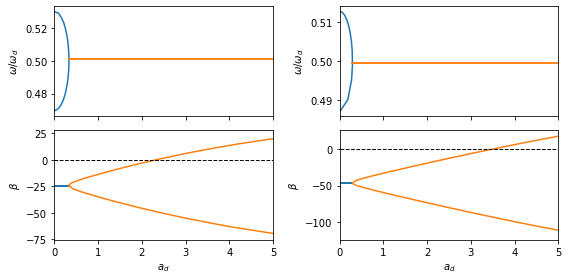

[(2.3301481809877886+3.262377182251287e-05j), (3.448539095013456+3.563216697126263e-07j)]


In [13]:
ad0s=[]
vn0s=[]
wn0s=[]
argsdict['epsu']=1E-3

for j in range(2):
    freq0=freq0s[j]
    omega=evals[order[j]]**0.5+1j*0
    argsdict['freq']=freq0
    argsdict['ad']=0

    lps,ls,mps,ms,nps,ns=viscid.makeindices(argsdict)
    kappax = (argsdict['kx'] + argsdict['k1x']*ms + argsdict['k2x']*ns)
    kappay = (argsdict['ky'] + argsdict['k1y']*ms + argsdict['k2y']*ns)
    kappa = (kappax**2+kappay**2)**0.5
    kappapx = (argsdict['kx'] + argsdict['k1x']*mps + argsdict['k2x']*nps)
    kappapy = (argsdict['ky'] + argsdict['k1y']*mps + argsdict['k2y']*nps)
    S = (- np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))
    C = (np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))

    #right preconditioner
    shape_flat=((2*argsdict['Nx']+1)*(2*argsdict['Ny']+1),(2*argsdict['Nx']+1)*(2*argsdict['Ny']+1))
    shape2=((2*argsdict['Nx']+1),(2*argsdict['Ny']+1),(2*argsdict['Nx']+1),(2*argsdict['Ny']+1))
    A2=argsdict['g']*(argsdict['rho']**2*(kappax*kappapx+kappay*kappapy)/kappa*S)
    argsdict['preconditioner']=np.linalg.inv(A2.reshape(shape_flat)).reshape(shape2)

    argsdict['precondition_axes']=((6,7),(0,1))
    argsdict['precondition_order']=(0,1,2,3,4,5,6,7)
        
    argsdict['freq']=freq0s[j]
    ind=np.argmin(np.abs(np.imag(omegas03[j])))
    ad0=ads03[j][ind]
    v0=vs03[j][ind]
    w0=ws03[j][ind]
    if np.min(omegas02[j])<0:
        ind=np.argmin(np.abs(np.imag(omegas02[j])))
        ad0=ads02[j][ind]
        v0=vs02[j][ind]
        w0=ws02[j][ind]
    ads,vs,ws=viscid.rayleigh_mat(ad0,v0,w0,mat,argsdict,mat2)
    ad0s=ad0s+[ads[-1]]
    vn0s=vn0s+[vs[-1]]
    wn0s=wn0s+[ws[-1]]
    
plt.subplots(2,2,figsize=(8,4))

for j in range(2):
    plt.subplot(2,2,j+1)
    plt.plot(ads01[j],np.real(omegas01[j])/(2*np.pi*freq0s[j]),c=colors[0])
    plt.plot(ads02[j],np.real(omegas02[j])/(2*np.pi*freq0s[j]),c=colors[1])
    plt.plot(ads03[j],np.real(omegas03[j])/(2*np.pi*freq0s[j]),c=colors[1])
    plt.xlim(0,admax)

    plt.gca().set_xticks(plt.gca().get_xticks(),['']*len(plt.gca().get_xticks()))
    plt.ylabel(r'$\omega/\omega_d$')

    plt.subplot(2,2,j+3)
    plt.plot(ads01[j],-np.imag(omegas01[j]),c=colors[0])
    plt.plot(ads02[j],-np.imag(omegas02[j]),c=colors[1])
    plt.plot(ads03[j],-np.imag(omegas03[j]),c=colors[1])
    plt.plot([0,admax],[0,0],ls='--',color='black',lw=1)
    plt.ylabel(r'$\beta$')
    plt.xlabel('$a_d$')
    plt.xlim(0,admax)


plt.tight_layout()
plt.show()
print(ad0s)


[[4.98425758 0.        ]
 [5.28633379 0.        ]
 [5.58841001 0.        ]
 [5.89048623 0.        ]
 [6.19256244 0.        ]
 [6.49463866 0.        ]
 [6.79671488 0.        ]
 [7.09879109 0.        ]
 [7.40086731 0.        ]
 [7.70294353 0.        ]
 [7.85398163 0.15114995]
 [7.85398163 0.45344984]
 [7.85398163 0.75574974]
 [7.85398163 1.05804963]
 [7.85398163 1.36034952]
 [7.85398163 1.66264942]
 [7.85398163 1.96494931]
 [7.85398163 2.26724921]
 [7.85398163 2.5695491 ]
 [7.85398163 2.87184899]
 [7.85398163 3.17414889]
 [7.85398163 3.47644878]
 [7.85398163 3.77874868]
 [7.85398163 4.08104857]
 [7.85398163 4.38334846]
 [7.59218225 4.38334846]
 [7.33038286 4.23219852]
 [7.06858347 4.08104857]
 [6.80678408 3.92989862]
 [6.54498469 3.77874868]
 [6.28318531 3.62759873]
 [6.02138592 3.47644878]]
32
0 19.93873071855976 4.984257575406883 0.0


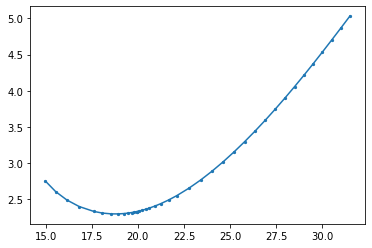

14.97906481207815 31.50033980342872 18.90560736362685 (2.29753352882918-0.003425966608040979j)
0.11481248121708632
1 18.90560736362685 5.28633379209821 0.0


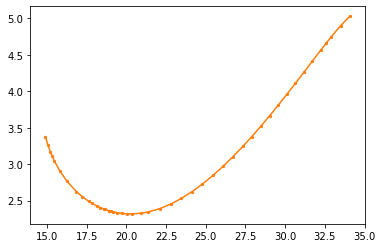

14.906534525549866 34.072728211812354 20.349325906764566 (2.3164615059367546+0.005082783399076162j)
0.22375265322625637
2 20.349325906764566 5.588410008789536 0.0


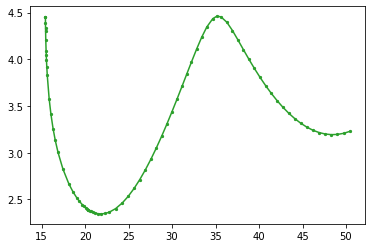

15.423329405507609 50.436686202365635 21.825590681750317 (2.3441723755910053+0.0036623576109200808j)
0.3207651739940047
3 21.825590681750317 5.890486225480862 0.0


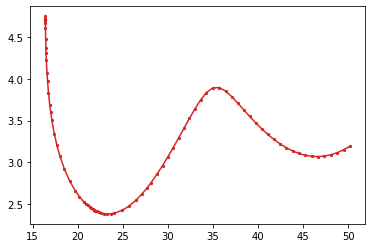

16.42767471861692 50.14352501604044 23.215831976431733 (2.3804063087967915+0.001254556174498118j)
0.39946703519672155
4 23.215831976431733 6.192562442172188 0.0


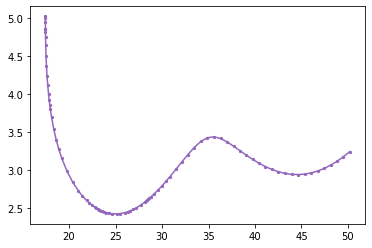

17.452355788425553 50.200063145130265 25.119462396350183 (2.4228808390363574-0.012339867030809942j)
0.4790286561474204
5 25.119462396350183 6.494638658863514 0.0


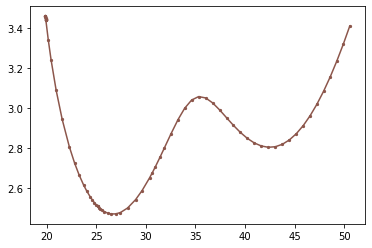

19.855240392059464 50.57678686415871 26.46198519835034 (2.471494389763042+0.021925187340917453j)
0.5533732259646058
6 26.46198519835034 6.796714875554841 0.0


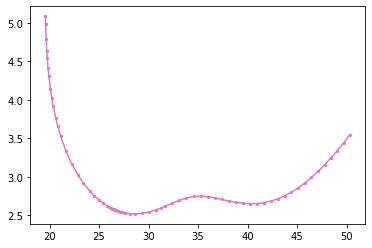

19.58504700084936 50.31984475612025 28.63512023977406 (2.5194850433396003+0.001890637420970879j)
0.6299486123025417
7 28.63512023977406 7.0987910922461674 0.0


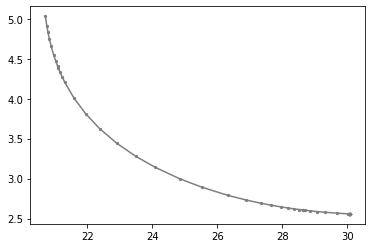

20.706777958417593 30.070307378044973 30.060934743661154 (2.5581374300395705+0.035588990635568404j)
0.7031615623272955
8 30.060934743661154 7.400867308937493 0.0


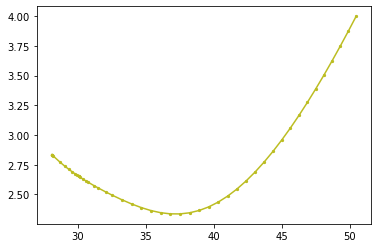

28.088505644536387 50.48054369570327 37.513056260371975 (2.3350623621147877+0.025346637196819274j)
0.779426135122776
9 37.513056260371975 7.702943525628819 0.0


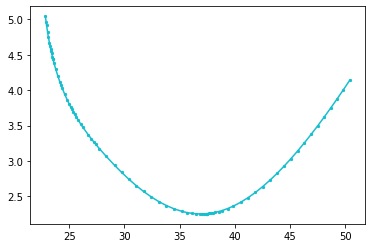

22.83460283677685 50.41847489189776 36.80403705233625 (2.253615319750295-0.00280875121520728j)
0.8563098991289735
10 36.80403705233625 7.853981633974483 0.15114994701951814


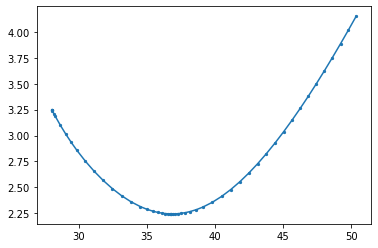

28.02692340037171 50.35262680109171 36.80403705233625 (2.2432137818383393+3.945063227585017e-05j)
0.9364753910340369
11 36.80403705233625 7.853981633974483 0.45344984105855446


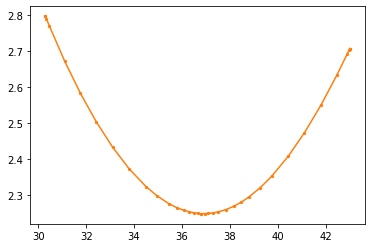

30.295127852873843 43.00691020342947 36.80403705233625 (2.247695254737706+5.473308519045375e-05j)
1.016675320919603
12 36.80403705233625 7.853981633974483 0.7557497350975907


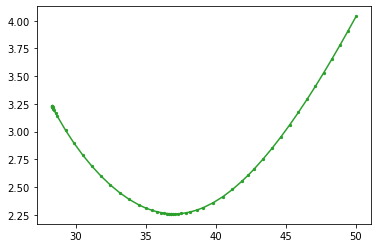

28.294606640549407 50.01027221676532 36.80403705233625 (2.258371553924772+6.145971323631559e-06j)
1.0962131372652948
13 36.80403705233625 7.853981633974483 1.058049629136627


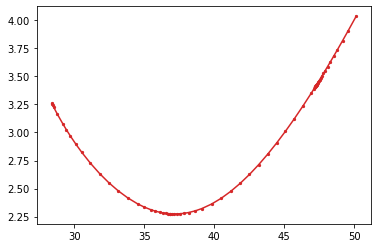

28.393599723989613 50.12837411105135 37.08767124067832 (2.274120101400733-0.0011913942638351058j)
1.1723629320040345
14 37.08767124067832 7.853981633974483 1.3603495231756633


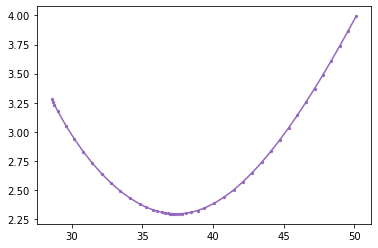

28.584608275916192 50.123146135133574 37.37149430352217 (2.294157432318469+0.0006894043480941223j)
1.2487664809450507
15 37.37149430352217 7.853981633974483 1.6626494172146995


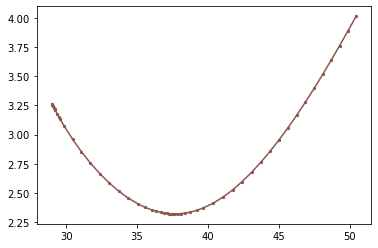

28.977795009478633 50.46060679390716 37.37149430352217 (2.318674531710819+1.4926367849319705e-05j)
1.4202390010468662
16 37.37149430352217 7.853981633974483 1.964949311253736


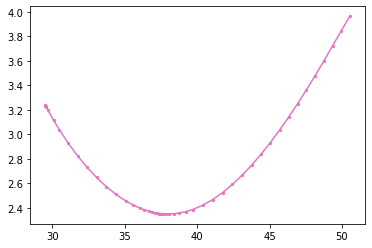

29.517460525416052 50.54062358806836 37.37149430352217 (2.3518555220757444-6.964884480148816e-05j)
1.50189102999866
17 37.37149430352217 7.853981633974483 2.267249205292772


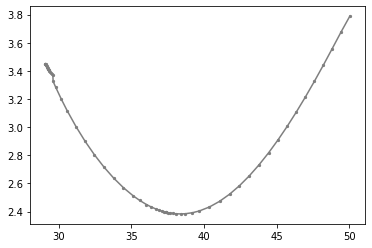

29.078414784915008 50.038799199453635 38.39807314583715 (2.3838173009683428-0.0033195461483359946j)
1.581889484077692
18 38.39807314583715 7.853981633974482 2.5695490993318084


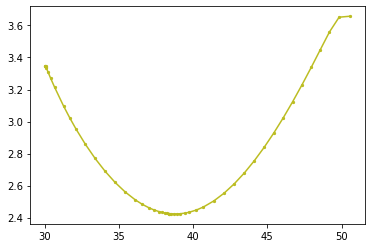

30.054427351112718 50.5504186695695 38.89314709696956 (2.423351753022871-0.000979924081016474j)
1.660149313043803
19 38.89314709696956 7.853981633974482 2.8718489933708446


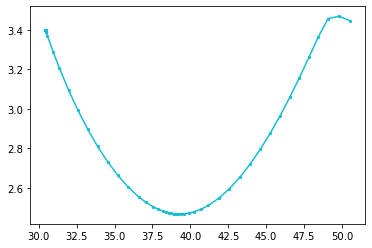

30.439109589042864 50.51219986168816 39.388528589441044 (2.4674738092251243-0.00044009659571742944j)
1.741004478186369
20 39.388528589441044 7.853981633974482 3.174148887409881


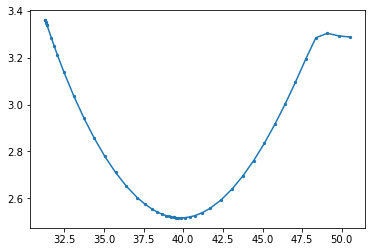

31.308361622072255 50.503680158989056 39.88475606041771 (2.516032901665619+8.6812817743272e-05j)
1.8257533102296293
21 39.88475606041771 7.853981633974482 3.4764487814489176


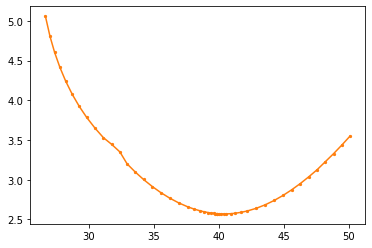

26.668803049609892 50.087277066117835 40.38064857828994 (2.569083974785692+0.00021190012032968087j)
1.9122646362520754
22 40.38064857828994 7.853981633974482 3.778748675487954


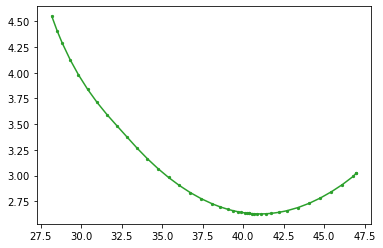

28.189643296976826 46.97086961674106 41.08883181507087 (2.626343078935541+3.0923059017861467e-06j)
1.998386633116752
23 41.08883181507087 7.853981633974482 4.08104856952699


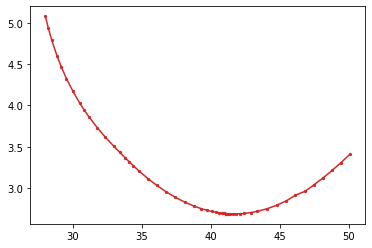

28.000481859778315 50.08460724744434 41.797373683421114 (2.687358128387653-0.0019313977046828525j)
2.067796483170241
24 41.797373683421114 7.853981633974482 4.383348463566026


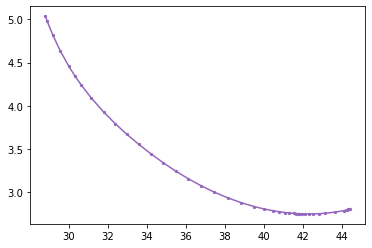

28.81564376421204 44.39137260641501 42.29235352684256 (2.747621006109314-9.907842032017141e-05j)
2.144009376876056
25 42.29235352684256 7.592182246175333 4.383348463566026


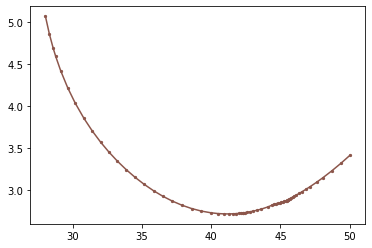

28.037808167740284 50.00045582827993 41.266855242003174 (2.7124991357001242-0.0010163773520371476j)
2.217333209235221
26 41.266855242003174 7.330382858376184 4.232198516546508


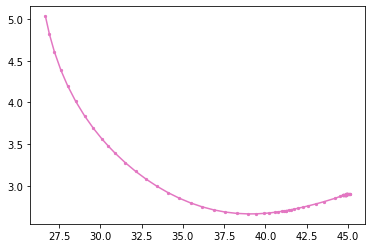

26.676398797722403 45.108504432672895 38.971332421397754 (2.6628117528171136+0.0004951009477977807j)
2.297418565955013
27 38.971332421397754 7.068583470577034 4.08104856952699


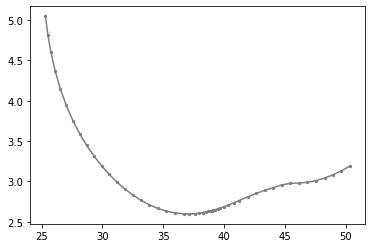

25.313951479516867 50.31510866394411 37.143450276302545 (2.598561472574573-0.0012846807099113576j)
2.3758358899503946
28 37.143450276302545 6.8067840827778845 3.929898622507472


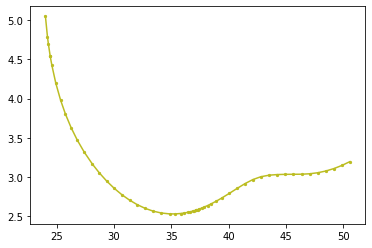

24.019849170914274 50.555265091973226 35.32481508230541 (2.5295859637267633+0.002318990431738208j)
2.4491479941643775
29 35.32481508230541 6.544984694978735 3.778748675487954


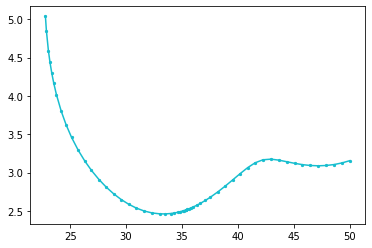

22.787287571695042 50.00005538324046 33.51054452196019 (2.4616699453332576-0.0010148625953800981j)
2.5204418431967497
30 33.51054452196019 6.283185307179586 3.6275987284684357


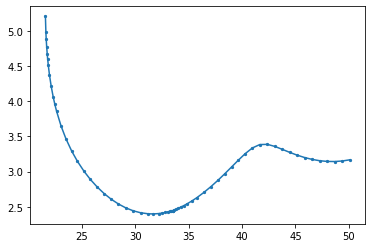

21.571640538268746 50.0893073611156 31.694125088491383 (2.397158435488038-0.0011392689401256493j)
2.592840977013111
31 31.694125088491383 6.021385919380436 3.4764487814489176


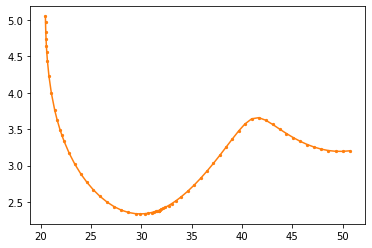

20.459192777996602 50.697311643219194 29.887122765510203 (2.3372351426123426-0.001823176053759564j)
2.669879203196615
0 51.55588216913697 4.984257575406883 0.0


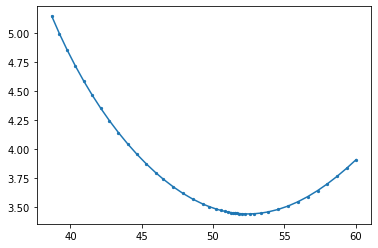

38.690061459694874 60.041387558574236 52.580954688662054 (3.4420087161710593-0.00022412578198806402j)
2.8512124409899116
1 52.580954688662054 5.28633379209821 0.0


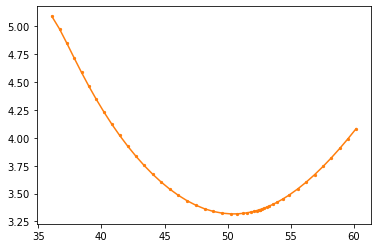

36.07328177041943 60.167467883561365 50.28498740288225 (3.317183797042332-0.00013058804408574553j)
2.9407855081371963
2 50.28498740288225 5.588410008789536 0.0


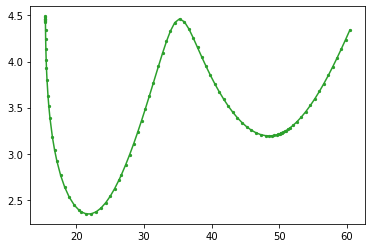

15.420848046600554 60.411494064130004 48.467080875426134 (3.193069484048215-0.00086771485658256j)
3.0144684510305524
3 48.467080875426134 5.890486225480862 0.0


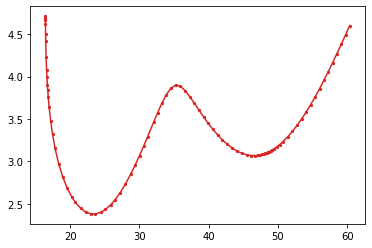

16.427868815775117 60.373994987732104 46.64709623422973 (3.0687089023526104-0.00018248004633182325j)
3.0905242301523685
4 46.64709623422973 6.192562442172188 0.0


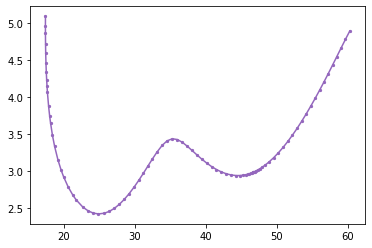

17.4594374121465 60.30660780788526 44.35339787024744 (2.940698552479061+0.0006041251233789739j)
3.1616496690548956
5 44.35339787024744 6.494638658863514 0.0


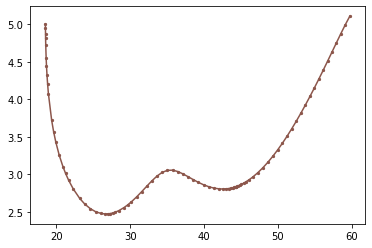

18.50979243190331 59.750472452989655 42.5357989385224 (2.8036184135499638-0.00025858733549968913j)
3.232265641912818
6 42.5357989385224 6.796714875554841 0.0


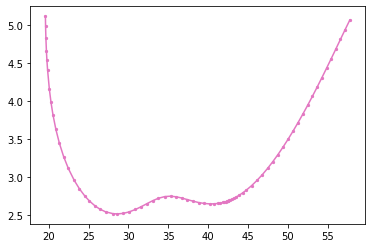

19.582058835300906 57.791906817607526 40.24005117173177 (2.650931095220046-0.0014181619916263655j)
3.3100420623086393
7 40.24005117173177 7.0987910922461674 0.0


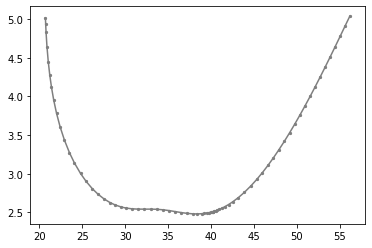

20.71177018651594 56.150316869621 38.41884495148134 (2.4815875112538928-0.0009465888268365881j)
3.3885583579540253
8 38.41884495148134 7.400867308937493 0.0


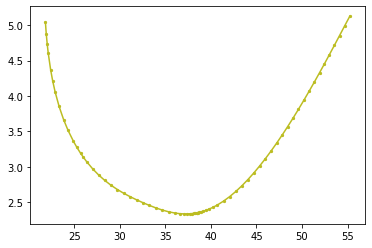

21.828576399845428 55.240642117136886 37.06087492297297 (2.3343218906071406-6.940337295785499e-05j)
3.466018585022539
9 37.06087492297297 7.702943525628819 0.0


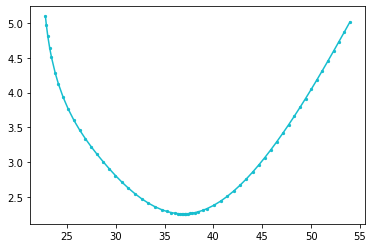

22.79359343557292 53.964941400529305 37.06087492297297 (2.252854018534159+1.6280837495476506e-05j)
3.5435167402029037
10 37.06087492297297 7.853981633974483 0.15114994701951814


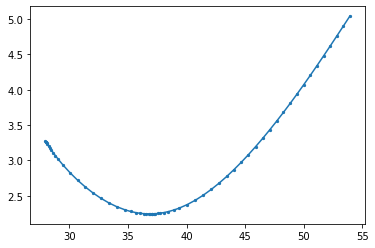

27.945033425100487 53.9421824632127 36.91930143369606 (2.243414702685736+8.59873219782135e-05j)
3.619268013164401
11 36.91930143369606 7.853981633974483 0.45344984105855446


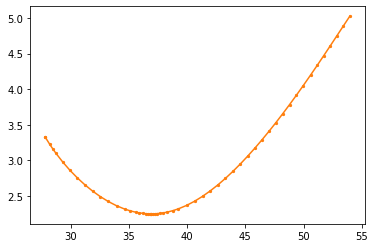

27.81917355421775 53.96304536778234 36.91930143369606 (2.247673753256528-9.744524831866255e-06j)
3.693084514234215
12 36.91930143369606 7.853981633974483 0.7557497350975907


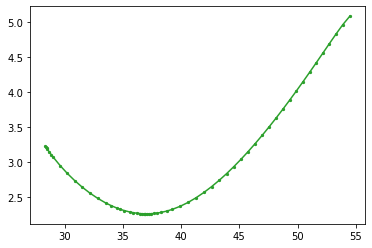

28.34145248588025 54.48035070790255 36.91930143369606 (2.2577442286003246-2.2230959430689527e-05j)
3.764760090969503
13 36.91930143369606 7.853981633974483 1.058049629136627


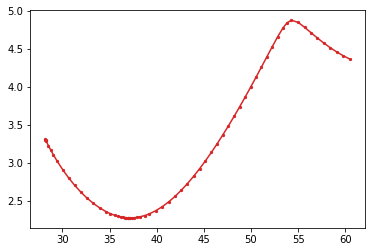

28.20152652975301 60.47628034184347 36.91930143369606 (2.273767740984311+3.8763004910149864e-05j)
3.838806205894798
14 36.91930143369606 7.853981633974483 1.3603495231756633


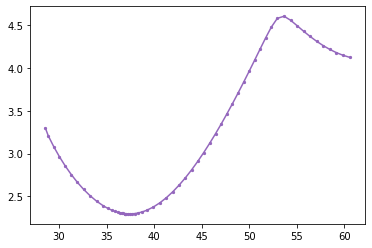

28.573514501771367 60.565914979128344 37.41529416500851 (2.2941468830446134-0.000894456153237604j)
3.9115390512160957
15 37.41529416500851 7.853981633974483 1.6626494172146995


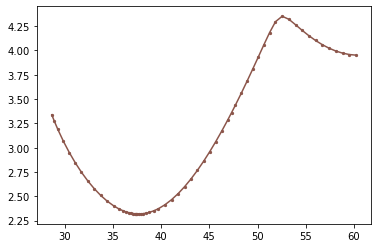

28.6813028571189 60.22212237971424 37.69872031916007 (2.3192156583495622+2.122538028662473e-05j)
3.9943522913381457
16 37.69872031916007 7.853981633974483 1.964949311253736


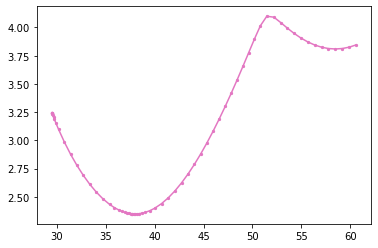

29.47047033895721 60.615503143838545 37.98985666978875 (2.349105230306965-0.00037656482442530864j)
4.0763189741410315
17 37.98985666978875 7.853981633974483 2.267249205292772


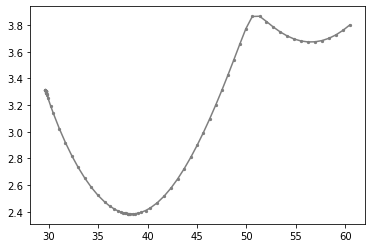

29.669153706895106 60.462244451254755 38.272811445881146 (2.3839305776528827-0.0001420939784932088j)
4.259178264066577
18 38.272811445881146 7.853981633974482 2.5695490993318084


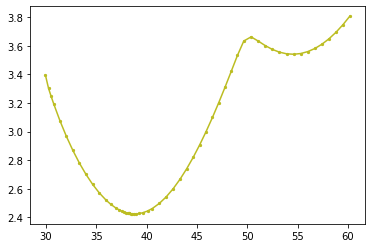

29.949883775348503 60.19430975040595 38.7679190023694 (2.4232821196972623-0.000501517800183213j)
4.339861519169062
19 38.7679190023694 7.853981633974482 2.8718489933708446


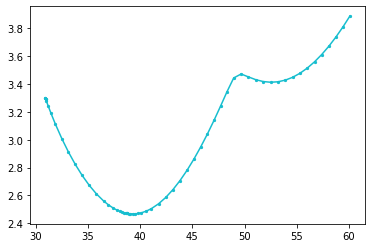

30.911430524436938 60.09011929863878 39.26389412568999 (2.4673618520142178-0.0006143336293903741j)
4.41799458488822
20 39.26389412568999 7.853981633974482 3.174148887409881


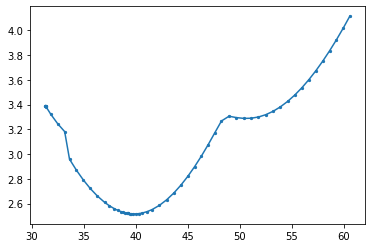

31.302641508794235 60.55704294211686 39.7589875749217 (2.5160631249140395-0.000981343877018266j)
4.4973550592549145
21 39.7589875749217 7.853981633974482 3.4764487814489176


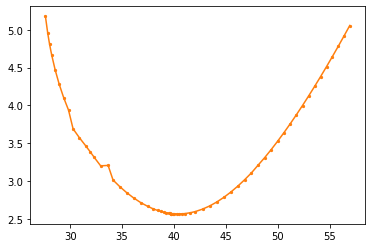

27.605584553173088 56.94490610988232 40.46648192091507 (2.569095211463382-0.0006476913750493667j)
4.571665974333882
22 40.46648192091507 7.853981633974482 3.778748675487954


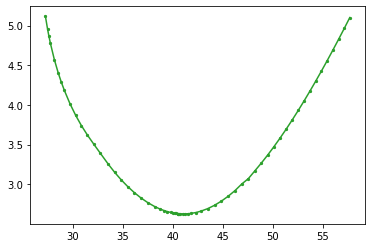

27.24747180007003 57.673541895896115 40.96298241040815 (2.626411489975354+0.0006211700663890939j)
4.652329517062753
23 40.96298241040815 7.853981633974482 4.08104856952699


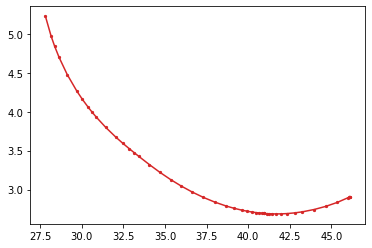

27.81524732444114 46.10816062855537 41.671145850384555 (2.6872811652229105+0.0004265119532898446j)
4.744480587076396
24 41.671145850384555 7.853981633974482 4.383348463566026


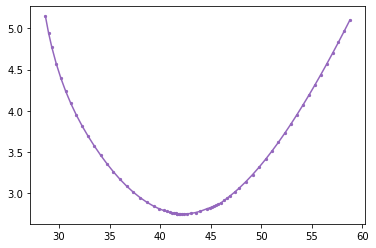

28.64998630489174 58.746533390704556 42.37927354849263 (2.7476992143472363+0.000813500272158548j)
4.820800251327455
25 42.37927354849263 7.592182246175333 4.383348463566026


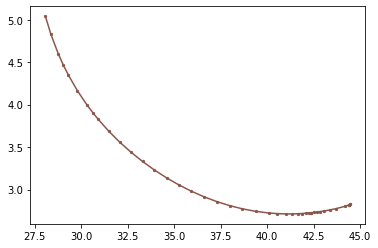

28.072556759913937 44.45062215538497 41.03573275045611 (2.7125636829078417+0.0004398086181356909j)
4.899436320178211
26 41.03573275045611 7.330382858376184 4.232198516546508


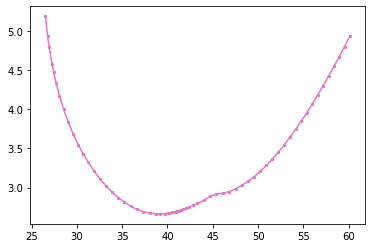

26.5336207535587 60.11895312115476 39.21498437589993 (2.6628654955559683+0.0016344106351853277j)
4.975288338959217
27 39.21498437589993 7.068583470577034 4.08104856952699


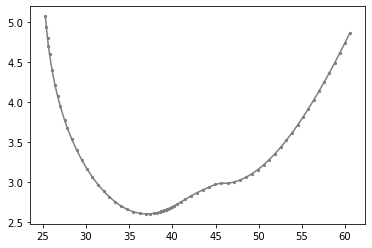

25.292159210416575 60.54305912124523 36.910637097064736 (2.598419306184279-0.0019088717359921608j)
5.051109982188791
28 36.910637097064736 6.8067840827778845 3.929898622507472


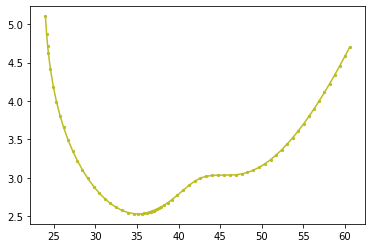

23.99147531916609 60.57376975042823 35.093009634708416 (2.5290643002134834+0.0006233986831669879j)
5.127633312251419
29 35.093009634708416 6.544984694978735 3.778748675487954


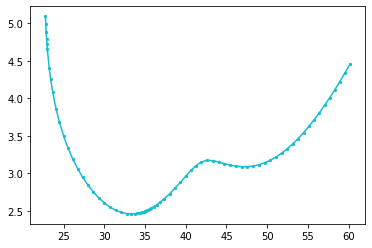

22.767917336357787 60.14196181997627 33.27775014416595 (2.461240347311969+0.0031893809494686755j)
5.205421994905919
30 33.27775014416595 6.283185307179586 3.6275987284684357


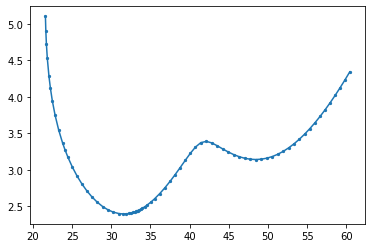

21.58755408159573 60.452566129730265 31.457833507004537 (2.3971676134129134-0.0021369602490998517j)
5.285886884201318
31 31.457833507004537 6.021385919380436 3.4764487814489176


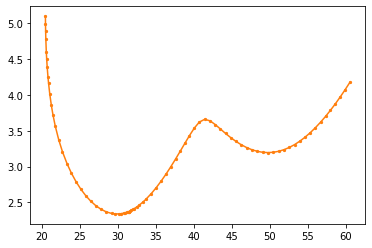

20.45513908302454 60.49692247627738 29.640118389766315 (2.337986883508466+0.00184409947947901j)
5.367733050137758


In [14]:
start=timeit.default_timer()
adssweep=[]
freqsweep=[]
vssweep=[]
wssweep=[]
dirsweep=[]
dssweep=[]
argsdict['verbose']=0
argsdict['lambdamax']=admax

ds=5E-1
ds0=1E-1
argsdict['dsmax']=ds
argsdict['ds']=ds0
argsdict['dsmin']=1E-8

argsdict['epsu']=1E-2
argsdict['epsl']=1E-2
argsdict['dmu_fd']=1E-4
argsdict['epstp']=5E-1
argsdict['epdir']=1E-3
argsdict['thmu']=5E-1
argsdict['thl']=5E0
argsdict['thu']=1E-4

argsdict['itmax']=10
argsdict['Nsteps']=5000

print(ks)
print(len(ks))
load=True
overwrite=True

l=0

for j in range(2):
    ad0=ad0s[j]
    vs0=vn0s[j]
    ws0=wn0s[j]
    freq0=freq0s[j]
    
    argsdict['freq']=freq0
    argsdict['kx']=ks[0][0]
    argsdict['ky']=ks[0][1]
    
    lps,ls,mps,ms,nps,ns=viscid.makeindices(argsdict)
    kappax = (argsdict['kx'] + argsdict['k1x']*ms + argsdict['k2x']*ns)
    kappay = (argsdict['ky'] + argsdict['k1y']*ms + argsdict['k2y']*ns)
    kappa = (kappax**2+kappay**2)**0.5
    kappapx = (argsdict['kx'] + argsdict['k1x']*mps + argsdict['k2x']*nps)
    kappapy = (argsdict['ky'] + argsdict['k1y']*mps + argsdict['k2y']*nps)
    S = (- np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))
    C = (np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))

    #right preconditioner
    shape_flat=((2*argsdict['Nx']+1)*(2*argsdict['Ny']+1),(2*argsdict['Nx']+1)*(2*argsdict['Ny']+1))
    shape2=((2*argsdict['Nx']+1),(2*argsdict['Ny']+1),(2*argsdict['Nx']+1),(2*argsdict['Ny']+1))
    A2=argsdict['g']*(argsdict['rho']**2*(kappax*kappapx+kappay*kappapy)/kappa*C)
    argsdict['preconditioner']=np.linalg.pinv(A2.reshape(shape_flat)).reshape(shape2)

    argsdict['precondition_axes']=((6,7),(0,1))
    argsdict['precondition_order']=(0,1,2,3,4,5,6,7)

    for i in range(len(ks)):
        kx=ks[i][0]
        ky=ks[i][1]
        print(i,freq0,kx,ky)
        if not os.path.exists('data/experiment/%iads.npy'%(l)) or not load:
            argsdict['freq']=freq0
            if(argsdict['kx']!=kx):
                argsdict['par']='kx'
                argsdict['pari']=np.min([kx,argsdict['kx']])
                argsdict['parf']=np.max([kx,argsdict['kx']])

                argsdict['ds']=np.sign(kx-argsdict['kx'])*1E-4
                ads1,vs1,ws1,pars1,dirs1,dss1=viscid.pseudocont(ad0, vs0, ws0, mat, argsdict, mat2)
                argsdict['kx']=kx
                ads1,vs1,ws1=viscid.rayleigh_mat(ads1[-1], vs1[-1], ws1[-1], mat, argsdict, mat2)
                ad0=ads1[-1]
                vs0=vs1[-1]
                ws0=ws1[-1]
            if(argsdict['ky']!=ky):
                argsdict['par']='ky'
                argsdict['pari']=np.min([ky,argsdict['ky']])
                argsdict['parf']=np.max([ky,argsdict['ky']])

                argsdict['ds']=np.sign(ky-argsdict['ky'])*1E-4
                ads1,vs1,ws1,pars1,dirs1,dss1=viscid.pseudocont(ad0, vs0, ws0, mat, argsdict, mat2)
                argsdict['ky']=ky
                ads1,vs1,ws1=viscid.rayleigh_mat(ads1[-1], vs1[-1], ws1[-1], mat, argsdict, mat2)
                ad0=ads1[-1]
                vs0=vs1[-1]
                ws0=ws1[-1]

            lps,ls,mps,ms,nps,ns=viscid.makeindices(argsdict)
            kappax = (argsdict['kx'] + argsdict['k1x']*ms + argsdict['k2x']*ns)
            kappay = (argsdict['ky'] + argsdict['k1y']*ms + argsdict['k2y']*ns)
            kappa = (kappax**2+kappay**2)**0.5
            kappapx = (argsdict['kx'] + argsdict['k1x']*mps + argsdict['k2x']*nps)
            kappapy = (argsdict['ky'] + argsdict['k1y']*mps + argsdict['k2y']*nps)
            S = (- np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))
            C = (np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))

            #right preconditioner
            shape_flat=((2*argsdict['Nx']+1)*(2*argsdict['Ny']+1),(2*argsdict['Nx']+1)*(2*argsdict['Ny']+1))
            shape2=((2*argsdict['Nx']+1),(2*argsdict['Ny']+1),(2*argsdict['Nx']+1),(2*argsdict['Ny']+1))
            A2=argsdict['g']*(argsdict['rho']**2*(kappax*kappapx+kappay*kappapy)/kappa*C)
            argsdict['preconditioner']=np.linalg.pinv(A2.reshape(shape_flat)).reshape(shape2)

            argsdict['precondition_axes']=((6,7),(0,1))
            argsdict['precondition_order']=(0,1,2,3,4,5,6,7)

            argsdict['freq']=freq0
            argsdict['par']='freq'
            argsdict['pari']=minfreq
            argsdict['parf']=maxfreq

            argsdict['ds']=ds0
            ads2,vs2,ws2,pars2,dirs2,dss2=viscid.pseudocont(ad0, vs0, ws0, mat, argsdict, mat2, real=1)
            argsdict['freq']=freq0        
            argsdict['ds']=-ds0
            ads3,vs3,ws3,pars3,dirs3,dss3=viscid.pseudocont(ad0, vs0, ws0, mat, argsdict, mat2, real=1) 
            

            freqsweep=freqsweep+[np.flip(pars3).tolist()+pars2]
            adssweep=adssweep+[np.flip(ads3).tolist()+ads2]
            vssweep=vssweep+[np.flip(vs3,axis=0).tolist()+vs2]
            wssweep=wssweep+[np.flip(ws3,axis=0).tolist()+ws2]
            dirsweep=dirsweep+[np.flip(dirs3,axis=0).tolist()+dirs2]
            dssweep=dssweep+[np.flip(dss3,axis=0).tolist()+dss2]
            if overwrite:
                np.save('data/experiment/%iads.npy'%(l),adssweep[l])
                np.save('data/experiment/%ivs.npy'%(l),vssweep[l])
                np.save('data/experiment/%iws.npy'%(l),wssweep[l])
                np.save('data/experiment/%ifreqs.npy'%(l),freqsweep[l])
                np.save('data/experiment/%idirs.npy'%(l),dirsweep[l])
                np.save('data/experiment/%idss.npy'%(l),dssweep[l])

        else:
            adssweep=adssweep+[np.load('data/experiment/%iads.npy'%(l))]
            freqsweep=freqsweep+[np.load('data/experiment/%ifreqs.npy'%(l))]
            argsdict['kx']=kx
            argsdict['ky']=ky

        plt.plot(freqsweep[l],np.abs(np.real(adssweep[l])),c=colors[i%len(colors)])
        plt.scatter(freqsweep[l],np.abs(np.real(adssweep[l])),c=colors[i%len(colors)],s=5)
        plt.show() 
            
        peaks,pprop=find_peaks(-np.abs(adssweep[-1]))
        ind=peaks[np.argmin(np.abs(np.array(freqsweep[-1])[peaks]-freq0))]
        ad0=adssweep[-1][ind]
        if vssweep != []:
            vs0=np.array(vssweep[-1][ind])
            ws0=np.array(wssweep[-1][ind])
        freq0=freqsweep[-1][ind]
        print(freqsweep[-1][0],freqsweep[-1][-1],freq0,ad0)
        
        l=l+1

        stop=timeit.default_timer()
        print(stop-start)

### Viscid instability boundary for As=0

In [15]:
argsdict['ad']=0
argsdict['As']=0
argsdict['kx']=ks[0][0]
argsdict['ky']=ks[0][1]
argsdict['verbose']=1
argsdict['dsmin']=1E-4


def mat0(omega,argsdict):
        E,F=viscid.viscid_mat2d(omega,argsdict)
        shape=E.shape
        E_shaped=E.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))
        F_shaped=F.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))

        return (np.tensordot(E_shaped,argsdict['preconditioner'],axes=argsdict['precondition_axes'])-argsdict['ad']*np.tensordot(F_shaped,argsdict['preconditioner'],axes=argsdict['precondition_axes'])).transpose(argsdict['precondition_order']).reshape(shape).T
def mat3(omega,argsdict):
        E,F=viscid.viscid_mat2d(omega,argsdict)
        shape=E.shape
        E_shaped=E.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))
        F_shaped=F.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))

        return (-np.tensordot(F_shaped,argsdict['preconditioner'],axes=argsdict['precondition_axes'])).transpose(argsdict['precondition_order']).reshape(shape).T

def mat(ad,argsdict):
    E,F=viscid.viscid_mat2d(2*np.pi*argsdict['freq']/2,argsdict)
    shape=E.shape
    E_shaped=E.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))
    F_shaped=F.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))

    return (np.tensordot(E_shaped,argsdict['preconditioner'],axes=argsdict['precondition_axes'])-ad*np.tensordot(F_shaped,argsdict['preconditioner'],axes=argsdict['precondition_axes'])).transpose(argsdict['precondition_order']).reshape(shape).T
def mat2(ad,argsdict):
    E,F=viscid.viscid_mat2d(2*np.pi*argsdict['freq']/2,argsdict)
    shape=E.shape
    E_shaped=E.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))
    F_shaped=F.reshape((3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1,3,2*argsdict['Nt']+1,2*argsdict['Nx']+1,2*argsdict['Ny']+1))

    return (-np.tensordot(F_shaped,argsdict['preconditioner'],axes=argsdict['precondition_axes'])).transpose(argsdict['precondition_order']).reshape(shape).T

Find the starting critical eigenvalues and eigenvectors by continuing the driving amplitude and finding the critical value at fixed frequency and wavenumber

[21.43115494 52.99607967]
n=0 dv=1.421581e-01 dw=4.999807e-01 dl=1.194945e-01
n=1 dv=3.127600e-03 dw=2.647731e-04 dl=9.776759e-02
n=2 dv=1.526732e-04 dw=1.713579e-05 dl=4.620096e-03
21.431154938307444 (22.480865199682036+4.830533399867583j)
newdir=(0.000,-0.000,0.316)
step=0 ds=1.000000e-02 ad=0.000000 lambda=70.625721+i15.175568 dir=(0.000, -0.000, 0.316)
pre dv=3.053e-03 dlambda=0.000e+00 dmu=3.152e-03 ad=0.003162 lr=70.625721 li=15.175568 mstp=0.000e+00
n=0 dv=9.491e-06 dlambda=1.265e-05 dmu=1.003e-11 ad=0.003162 lr=70.625106 li=15.175568 mstp=1.889e-04
m=0 direrr=2.160e-05 res=1.958e-03
deltadir=-1.756e-16 stp=(-0.061,0.000,0.316) newdir=(-0.061, 0.000, 0.316)
ds=1.000e-02 its=1 ad=0.003162 lambda=70.625106+15.175568i stp=(-0.061,0.000,0.316) mstp=1.889e-04
step=1 ds=1.000000e-02 ad=0.003162 lambda=70.625106+i15.175568 dir=(-0.061, 0.000, 0.316)
pre dv=3.053e-03 dlambda=8.391e-06 dmu=3.142e-03 ad=0.006324 lr=70.624492 li=15.175568 mstp=0.000e+00
n=0 dv=1.955e-05 dlambda=9.535e-06 d

n=0 dv=1.691e-03 dlambda=3.150e-04 dmu=2.945e-03 ad=0.235583 lr=68.854492 li=15.175568 mstp=3.131e-03
m=0 direrr=5.903e-03 res=2.103e-02
m=1 direrr=1.183e-28 res=1.459e-07
deltadir=-2.938e-03 stp=(-2.811,0.000,0.145) newdir=(-2.914, 0.000, 0.123)
ds=2.563e-01 its=1 ad=0.235583 lambda=68.854492+15.175568i stp=(-2.820,0.000,0.145) mstp=3.131e-03
step=16 ds=2.562891e-01 ad=0.235583 lambda=68.854492+i15.175568 dir=(-2.914, 0.000, 0.123)
pre dv=5.782e-02 dlambda=1.055e-02 dmu=2.486e-02 ad=0.267077 lr=68.107740 li=15.175568 mstp=-2.220e-16
n=0 dv=3.284e-03 dlambda=4.800e-04 dmu=6.463e-03 ad=0.258941 lr=68.073792 li=15.175568 mstp=5.902e-03
m=0 direrr=1.116e-02 res=2.877e-02
m=1 direrr=3.980e-27 res=3.008e-07
deltadir=-5.534e-03 stp=(-3.030,0.000,0.091) newdir=(-3.108, 0.000, 0.058)
ds=2.563e-01 its=1 ad=0.258941 lambda=68.073792+15.175568i stp=(-3.046,0.000,0.091) mstp=5.902e-03
step=17 ds=2.562891e-01 ad=0.258941 lambda=68.073792+i15.175568 dir=(-3.108, 0.000, 0.058)
pre dv=5.265e-02 dlambd

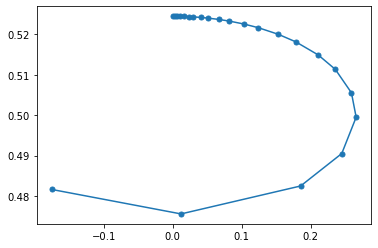

18 0.26669091599445505 (67.48268597580255+15.175568241944122j)
newdir=(0.000,3.153,0.024)
step=0 ds=1.000000e-01 ad=0.266691 lambda=67.482686+i15.175568 dir=(0.000, 3.153, 0.024)
pre dv=1.864e-02 dlambda=4.489e-03 dmu=1.891e-03 ad=0.269091 lr=67.482686 li=15.490881 mstp=-1.110e-16
n=0 dv=1.075e-02 dlambda=2.231e-03 dmu=1.362e-03 ad=0.267365 lr=67.482686 li=15.528449 mstp=1.807e-03
n=1 dv=2.725e-03 dlambda=2.283e-03 dmu=2.817e-04 ad=0.267008 lr=67.482686 li=15.486371 mstp=2.127e-03
m=0 direrr=4.848e-03 res=1.085e-02
m=1 direrr=5.097e-31 res=1.705e-04
deltadir=-2.415e-03 stp=(0.000,3.162,0.003) newdir=(0.000, 3.152, 0.025)
ds=1.000e-01 its=2 ad=0.267008 lambda=67.482686+15.486371i stp=(0.000,3.108,0.003) mstp=2.127e-03
step=1 ds=1.000000e-01 ad=0.267008 lambda=67.482686+i15.486371 dir=(0.000, 3.152, 0.025)
pre dv=1.873e-02 dlambda=4.483e-03 dmu=1.983e-03 ad=0.269526 lr=67.482686 li=15.801591 mstp=0.000e+00
n=0 dv=4.846e-03 dlambda=2.207e-03 dmu=7.097e-04 ad=0.270427 lr=67.482686 li=15.79

pre dv=1.171e-02 dlambda=7.168e-02 dmu=1.504e-01 ad=2.686503 lr=67.482686 li=45.659136 mstp=0.000e+00
n=0 dv=1.615e-03 dlambda=3.233e-03 dmu=6.156e-03 ad=2.709338 lr=67.482686 li=45.442470 mstp=7.541e-04
m=0 direrr=6.291e-04 res=6.315e-04
deltadir=0.000e+00 stp=(0.000,2.221,0.225) newdir=(0.000, 2.221, 0.225)
ds=2.563e+00 its=1 ad=2.709338 lambda=67.482686+45.442470i stp=(0.000,2.222,0.225) mstp=7.541e-04
step=17 ds=2.562891e+00 ad=2.709338 lambda=67.482686+i45.442470 dir=(0.000, 2.221, 0.225)
pre dv=1.232e-02 dlambda=6.644e-02 dmu=1.346e-01 ad=3.286253 lr=67.482686 li=51.134655 mstp=-1.110e-16
n=0 dv=1.785e-03 dlambda=3.968e-03 dmu=6.831e-03 ad=3.315733 lr=67.482686 li=50.832753 mstp=1.355e-03
m=0 direrr=7.714e-04 res=6.332e-04
deltadir=-1.589e-16 stp=(0.000,2.101,0.236) newdir=(0.000, 2.101, 0.236)
ds=3.844e+00 its=1 ad=3.315733 lambda=67.482686+50.832753i stp=(0.000,2.103,0.237) mstp=1.355e-03
step=18 ds=3.844336e+00 ad=3.315733 lambda=67.482686+i50.832753 dir=(0.000, 2.101, 0.236)


n=1 dv=5.207386e-03 dw=4.933278e-04 dl=1.491764e-02
n=2 dv=8.986726e-06 dw=1.296658e-06 dl=7.772867e-05
52.996079674135984 (55.507210518984664+11.503348562403678j)
newdir=(-0.000,0.000,0.316)
step=0 ds=1.000000e-02 ad=0.000000 lambda=174.381045+i36.138835 dir=(-0.000, 0.000, 0.316)
pre dv=1.418e-03 dlambda=0.000e+00 dmu=3.152e-03 ad=0.003162 lr=174.381045 li=36.138835 mstp=-2.220e-16
n=0 dv=2.148e-06 dlambda=7.091e-07 dmu=2.015e-13 ad=0.003162 lr=174.380918 li=36.138835 mstp=8.064e-06
m=0 direrr=1.587e-05 res=4.372e-04
deltadir=-1.755e-16 stp=(-0.013,0.000,0.316) newdir=(-0.013, 0.000, 0.316)
ds=1.000e-02 its=1 ad=0.003162 lambda=174.380918+36.138835i stp=(-0.013,0.000,0.316) mstp=8.064e-06
step=1 ds=1.000000e-02 ad=0.003162 lambda=174.380918+i36.138835 dir=(-0.013, 0.000, 0.316)
pre dv=1.418e-03 dlambda=7.091e-07 dmu=3.142e-03 ad=0.006325 lr=174.380791 li=36.138835 mstp=0.000e+00
n=0 dv=4.297e-06 dlambda=1.410e-06 dmu=1.007e-07 ad=0.006324 lr=174.380538 li=36.138835 mstp=3.187e-05
m=0

pre dv=3.137e-02 dlambda=2.931e-03 dmu=4.613e-02 ad=0.347114 lr=172.756863 li=36.138835 mstp=0.000e+00
n=0 dv=1.035e-03 dlambda=2.442e-04 dmu=2.695e-03 ad=0.343493 lr=172.713606 li=36.138835 mstp=2.420e-03
m=0 direrr=4.431e-03 res=8.071e-03
m=1 direrr=1.880e-27 res=2.063e-07
deltadir=-2.208e-03 stp=(-2.194,0.000,0.228) newdir=(-2.340, 0.000, 0.213)
ds=2.563e-01 its=1 ad=0.343493 lambda=172.713606+36.138835i stp=(-2.199,0.000,0.228) mstp=2.420e-03
step=17 ds=2.562891e-01 ad=0.343493 lambda=172.713606+i36.138835 dir=(-2.340, 0.000, 0.213)
pre dv=2.946e-02 dlambda=3.391e-03 dmu=3.899e-02 ad=0.398007 lr=172.113889 li=36.138835 mstp=-2.220e-16
n=0 dv=1.006e-03 dlambda=1.889e-04 dmu=2.622e-03 ad=0.394351 lr=172.080646 li=36.138835 mstp=1.857e-03
m=0 direrr=3.421e-03 res=7.242e-03
m=1 direrr=7.700e-27 res=1.813e-07
deltadir=-1.706e-03 stp=(-2.465,0.000,0.198) newdir=(-2.577, 0.000, 0.183)
ds=3.844e-01 its=1 ad=0.394351 lambda=172.080646+36.138835i stp=(-2.470,0.000,0.198) mstp=1.857e-03
step=

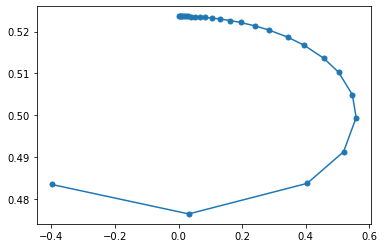

22 0.5608640442427637 (166.8350656122532+36.13883533533009j)
newdir=(0.000,3.156,0.020)
step=0 ds=1.000000e-01 ad=0.560864 lambda=166.835066+i36.138835 dir=(0.000, 3.156, 0.020)
pre dv=7.761e-03 dlambda=1.837e-03 dmu=1.269e-03 ad=0.562847 lr=166.835066 li=36.454440 mstp=2.220e-16
n=0 dv=1.165e-02 dlambda=1.927e-03 dmu=1.833e-03 ad=0.559988 lr=166.835066 li=36.596342 mstp=4.852e-03
n=1 dv=6.943e-03 dlambda=2.556e-03 dmu=5.421e-04 ad=0.559143 lr=166.835066 li=36.337871 mstp=7.002e-03
m=0 direrr=1.475e-02 res=1.480e-02
m=1 direrr=6.402e-27 res=2.312e-04
deltadir=-7.296e-03 stp=(0.000,3.151,-0.027) newdir=(0.000, 3.160, 0.011)
ds=1.000e-01 its=2 ad=0.559143 lambda=166.835066+36.337871i stp=(0.000,1.990,-0.017) mstp=7.002e-03
step=1 ds=1.000000e-01 ad=0.559143 lambda=166.835066+i36.337871 dir=(0.000, 3.160, 0.011)
pre dv=1.048e-02 dlambda=1.839e-03 dmu=7.015e-04 ad=0.560238 lr=166.835066 li=36.653908 mstp=-1.110e-16
n=0 dv=7.049e-03 dlambda=2.105e-03 dmu=3.054e-04 ad=0.559761 lr=166.835066 

pre dv=1.328e-02 dlambda=3.663e-02 dmu=1.331e-01 ad=2.471167 lr=166.835066 li=69.762987 mstp=0.000e+00
n=0 dv=4.241e-03 dlambda=1.920e-03 dmu=2.652e-03 ad=2.480398 lr=166.835066 li=69.698304 mstp=9.671e-05
m=0 direrr=5.662e-05 res=3.345e-04
deltadir=0.000e+00 stp=(0.000,2.573,0.184) newdir=(0.000, 2.573, 0.184)
ds=2.563e+00 its=1 ad=2.480398 lambda=166.835066+69.698304i stp=(0.000,2.573,0.184) mstp=9.671e-05
step=17 ds=2.562891e+00 ad=2.480398 lambda=166.835066+i69.698304 dir=(0.000, 2.573, 0.184)
pre dv=9.035e-03 dlambda=3.575e-02 dmu=1.192e-01 ad=2.951456 lr=166.835066 li=76.293342 mstp=-2.220e-16
n=0 dv=2.715e-03 dlambda=1.898e-03 dmu=2.447e-03 ad=2.961147 lr=166.835066 li=76.223430 mstp=1.087e-04
m=0 direrr=5.223e-05 res=3.227e-04
deltadir=0.000e+00 stp=(0.000,2.546,0.188) newdir=(0.000, 2.546, 0.188)
ds=3.844e+00 its=1 ad=2.961147 lambda=166.835066+76.223430i stp=(0.000,2.546,0.188) mstp=1.087e-04
step=18 ds=3.844336e+00 ad=2.961147 lambda=166.835066+i76.223430 dir=(0.000, 2.546, 

In [16]:
argsdict['kx']=ks[0][0]
argsdict['ky']=ks[0][1]
F,G=viscid.inviscid_mat_undriven(argsdict)
evals,revecs,levecs=eig(F,G,right=True,left=True)
order=np.argsort(np.real(evals))
freq0s=0.9*np.real(evals[order[:2]]**0.5/(2*np.pi/2)) #reduce the frequency a bit relative to inviscid case
print(freq0s)

argsdict['verbose']=3
argsdict['lambdamax']=np.inf
ds=1E-1
dsmax=1E1
argsdict['itmax']=10
argsdict['ds']=ds
argsdict['dsmax']=dsmax
argsdict['dsmin']=1E-4
argsdict['epsl']=1E-2
argsdict['epsu']=1E-2
argsdict['epstp']=1E0
argsdict['thmu']=1E1
argsdict['thl']=1E-1
argsdict['thu']=1E-4

ads01=[]
ads02=[]
ads03=[]
vs01=[]
vs02=[]
vs03=[]
ws01=[]
ws02=[]
ws03=[]
omegas01=[]
omegas02=[]
omegas03=[]
dirs01=[]

load=True
overwrite=True

start=timeit.default_timer()
for j in range(2):
    if not os.path.exists('data/experiment/%iads01_flat.npy'%(j)) or not load:
        omega=evals[order[j]]**0.5+1j*0
        E,F=viscid.viscid_mat2d(omega,argsdict)

        v=np.zeros((3,(2*argsdict['Nt']+1),(2*argsdict['Nx']+1),(2*argsdict['Ny']+1)),np.complex128)
        w=np.zeros((3,(2*argsdict['Nt']+1),(2*argsdict['Nx']+1),(2*argsdict['Ny']+1)),np.complex128)
        v[2,argsdict['Nt']]=revecs[:,order[j]].reshape((2*argsdict['Nx']+1,2*argsdict['Ny']+1))
        w[2,argsdict['Nt']]=levecs[:,order[j]].reshape((2*argsdict['Nx']+1,2*argsdict['Ny']+1))
        v=v.ravel()
        w=w.ravel()

        freq0=freq0s[j]
        omega=evals[order[j]]**0.5+1j*0
        argsdict['freq']=freq0
        argsdict['ad']=0

        lps,ls,mps,ms,nps,ns=viscid.makeindices(argsdict)
        kappax = (argsdict['kx'] + argsdict['k1x']*ms + argsdict['k2x']*ns)
        kappay = (argsdict['ky'] + argsdict['k1y']*ms + argsdict['k2y']*ns)
        kappa = (kappax**2+kappay**2)**0.5
        kappapx = (argsdict['kx'] + argsdict['k1x']*mps + argsdict['k2x']*nps)
        kappapy = (argsdict['ky'] + argsdict['k1y']*mps + argsdict['k2y']*nps)
        S = (- np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))
        C = (np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))

        #right preconditioner
        shape_flat=((2*argsdict['Nx']+1)*(2*argsdict['Ny']+1),(2*argsdict['Nx']+1)*(2*argsdict['Ny']+1))
        shape2=((2*argsdict['Nx']+1),(2*argsdict['Ny']+1),(2*argsdict['Nx']+1),(2*argsdict['Ny']+1))
        A2=argsdict['g']*(argsdict['rho']**2*(kappax*kappapx+kappay*kappapy)/kappa*S)
        argsdict['preconditioner']=np.linalg.inv(A2.reshape(shape_flat)).reshape(shape2)

        argsdict['precondition_axes']=((6,7),(0,1))
        argsdict['precondition_order']=(0,1,2,3,4,5,6,7)


        #starting frequency and driving
        omegas,vs,ws=viscid.rayleigh_mat(omega,v,np.conjugate(w),mat0,argsdict)
        omega0=omegas[-1]
        v0=vs[-1]
        w0=ws[-1]
        print(freq0,omegas[-1]/np.pi)
        argsdict['par']='ad'
        argsdict['pari']=0
        argsdict['parf']=admax
        argsdict['ds']=ds/10
        argsdict['dsmax']=dsmax
        omegas,vs,ws,pars,dirs,dss=viscid.pseudocont(omega0,v0,w0,mat0,argsdict,mat3=mat3, real=1)
        omegas01=omegas01+[omegas]
        vs01=vs01+[vs]
        ws01=ws01+[ws]
        ads01=ads01+[pars]
        dirs01=dirs01+[dirs]
        plt.plot(ads01[j],np.real(omegas01[j])/(2*np.pi*freq0s[j]),c=colors[0], marker='o', ms=5)
        plt.show()
        
        ind=np.argmax(pars)
        fomega=interp1d(np.arange(len(omegas)),omegas,kind='cubic')
        fv=interp1d(np.arange(len(omegas)),np.array(vs).T,kind='cubic')
        fw=interp1d(np.arange(len(omegas)),np.array(ws).T,kind='cubic')
        fpar=interp1d(np.arange(len(omegas)),pars,kind='cubic')
        fdir=interp1d(np.arange(len(omegas)),np.array(dirs).T,kind='cubic')

        if ind<len(pars)-3:
            if pars[ind-2]<pars[ind] and pars[ind+2]<pars[ind]:
                find=minimize_scalar(lambda x: -fpar(x),bracket=(ind-1,ind+1)).x
            else:
                find=minimize_scalar(lambda x: fpar(x),bracket=(ind-1,ind+1)).x
        else:
            find=ind
            
        omega0=complex(fomega(find))
        v0=fv(find)
        w0=fw(find)
        dir0=fdir(find)
        s=3*(2*argsdict['Nt']+1)*(2*argsdict['Nx']+1)*(2*argsdict['Ny']+1)
        newdir=np.zeros(dir0.shape)
        newdir[:s]=dir0[s:2*s]
        newdir[s:2*s]=-dir0[:s]
        newdir[2*s]=dir0[2*s+1]
        newdir[2*s+1]=-dir0[2*s]
        newdir[2*s+2]=2*dir0[2*s+2]
        dir0=newdir
        argsdict['ad']=fpar(find)
        print(ind,argsdict['ad'],omega0)
        argsdict['ds']=ds
        argsdict['dsmax']=dsmax
        omegas,vs,ws,pars,dirs,dss=viscid.pseudocont(omega0,v0,w0,mat0,argsdict,mat3=mat3,dir=dir0,real=-1)
        omegas02=omegas02+[omegas]
        vs02=vs02+[vs]
        ws02=ws02+[ws]
        ads02=ads02+[pars]
        argsdict['ds']=-ds*10
        argsdict['ad']=fpar(find)
        omegas,vs,ws,pars,dirs,dss=viscid.pseudocont(omega0,v0,w0,mat0,argsdict,mat3=mat3,dir=dir0,real=-1)
        argsdict['ds']=-argsdict['ds']
        omegas03=omegas03+[omegas]
        vs03=vs03+[vs]
        ws03=ws03+[ws]
        ads03=ads03+[pars]

        if overwrite:
            np.save('data/experiment/%iomegas01_flat.npy'%(j),omegas01[j])
            np.save('data/experiment/%iads01_flat.npy'%(j),ads01[j])
            np.save('data/experiment/%ivs01_flat.npy'%(j),vs01[j])
            np.save('data/experiment/%iws01_flat.npy'%(j),ws01[j])

            np.save('data/experiment/%iomegas02_flat.npy'%(j),omegas02[j])
            np.save('data/experiment/%iads02_flat.npy'%(j),ads02[j])
            np.save('data/experiment/%ivs02_flat.npy'%(j),vs02[j])
            np.save('data/experiment/%iws02_flat.npy'%(j),ws02[j])

            np.save('data/experiment/%iomegas03_flat.npy'%(j),omegas03[j])
            np.save('data/experiment/%iads03_flat.npy'%(j),ads03[j])
            np.save('data/experiment/%ivs03_flat.npy'%(j),vs03[j])
            np.save('data/experiment/%iws03_flat.npy'%(j),ws03[j])
    else:
        omegas01=omegas01+[np.load('data/experiment/%iomegas01_flat.npy'%(j))]
        ads01=ads01+[np.load('data/experiment/%iads01_flat.npy'%(j))]
        vs01=vs01+[np.load('data/experiment/%ivs01_flat.npy'%(j))]
        ws01=ws01+[np.load('data/experiment/%iws01_flat.npy'%(j))]

        omegas02=omegas02+[np.load('data/experiment/%iomegas02_flat.npy'%(j))]
        ads02=ads02+[np.load('data/experiment/%iads02_flat.npy'%(j))]
        vs02=vs02+[np.load('data/experiment/%ivs02_flat.npy'%(j))]
        ws02=ws02+[np.load('data/experiment/%iws02_flat.npy'%(j))]

        omegas03=omegas03+[np.load('data/experiment/%iomegas03_flat.npy'%(j))]
        ads03=ads03+[np.load('data/experiment/%iads03_flat.npy'%(j))]
        vs03=vs03+[np.load('data/experiment/%ivs03_flat.npy'%(j))]
        ws03=ws03+[np.load('data/experiment/%iws03_flat.npy'%(j))]


stop=timeit.default_timer()
print(stop-start)

n=0 dv=2.477788e-03 dw=1.658844e-02 dl=6.543619e-02
n=1 dv=1.343860e-05 dw=1.437155e-04 dl=6.873639e-04
n=0 dv=6.889720e-04 dw=4.288354e-03 dl=2.487587e-02
n=1 dv=1.127803e-06 dw=1.132086e-05 dl=6.319804e-05


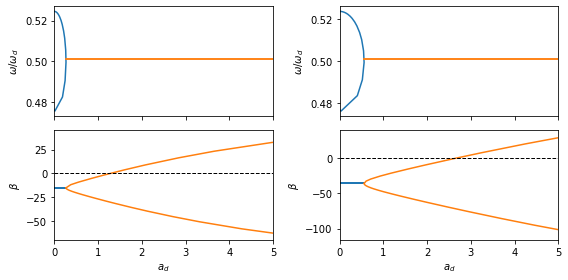

[(1.2829851988837528-5.74644063904153e-09j), (2.689560776091795-1.2245143357584942e-08j)]


In [17]:
ad0s=[]
vn0s=[]
wn0s=[]
argsdict['epsu']=1E-3

for j in range(2):
    freq0=freq0s[j]
    omega=evals[order[j]]**0.5+1j*0
    argsdict['freq']=freq0
    argsdict['ad']=0

    lps,ls,mps,ms,nps,ns=viscid.makeindices(argsdict)
    kappax = (argsdict['kx'] + argsdict['k1x']*ms + argsdict['k2x']*ns)
    kappay = (argsdict['ky'] + argsdict['k1y']*ms + argsdict['k2y']*ns)
    kappa = (kappax**2+kappay**2)**0.5
    kappapx = (argsdict['kx'] + argsdict['k1x']*mps + argsdict['k2x']*nps)
    kappapy = (argsdict['ky'] + argsdict['k1y']*mps + argsdict['k2y']*nps)
    S = (- np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))
    C = (np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))

    #right preconditioner
    shape_flat=((2*argsdict['Nx']+1)*(2*argsdict['Ny']+1),(2*argsdict['Nx']+1)*(2*argsdict['Ny']+1))
    shape2=((2*argsdict['Nx']+1),(2*argsdict['Ny']+1),(2*argsdict['Nx']+1),(2*argsdict['Ny']+1))
    A2=argsdict['g']*(argsdict['rho']**2*(kappax*kappapx+kappay*kappapy)/kappa*S)
    argsdict['preconditioner']=np.linalg.inv(A2.reshape(shape_flat)).reshape(shape2)

    argsdict['precondition_axes']=((6,7),(0,1))
    argsdict['precondition_order']=(0,1,2,3,4,5,6,7)
        
    argsdict['freq']=freq0s[j]
    ind=np.argmin(np.abs(np.imag(omegas03[j])))
    ad0=ads03[j][ind]
    v0=vs03[j][ind]
    w0=ws03[j][ind]
    if np.min(omegas02[j])<0:
        ind=np.argmin(np.abs(np.imag(omegas02[j])))
        ad0=ads02[j][ind]
        v0=vs02[j][ind]
        w0=ws02[j][ind]
    ads,vs,ws=viscid.rayleigh_mat(ad0,v0,w0,mat,argsdict,mat2)
    ad0s=ad0s+[ads[-1]]
    vn0s=vn0s+[vs[-1]]
    wn0s=wn0s+[ws[-1]]
    
plt.subplots(2,2,figsize=(8,4))

for j in range(2):
    plt.subplot(2,2,j+1)
    plt.plot(ads01[j],np.real(omegas01[j])/(2*np.pi*freq0s[j]),c=colors[0])
    plt.plot(ads02[j],np.real(omegas02[j])/(2*np.pi*freq0s[j]),c=colors[1])
    plt.plot(ads03[j],np.real(omegas03[j])/(2*np.pi*freq0s[j]),c=colors[1])
    plt.xlim(0,admax)

    plt.gca().set_xticks(plt.gca().get_xticks(),['']*len(plt.gca().get_xticks()))
    plt.ylabel(r'$\omega/\omega_d$')

    plt.subplot(2,2,j+3)
    plt.plot(ads01[j],-np.imag(omegas01[j]),c=colors[0])
    plt.plot(ads02[j],-np.imag(omegas02[j]),c=colors[1])
    plt.plot(ads03[j],-np.imag(omegas03[j]),c=colors[1])
    plt.plot([0,admax],[0,0],ls='--',color='black',lw=1)
    plt.ylabel(r'$\beta$')
    plt.xlabel('$a_d$')
    plt.xlim(0,admax)


plt.tight_layout()
plt.show()
print(ad0s)


[[4.98425758 0.        ]
 [5.28633379 0.        ]
 [5.58841001 0.        ]
 [5.89048623 0.        ]
 [6.19256244 0.        ]
 [6.49463866 0.        ]
 [6.79671488 0.        ]
 [7.09879109 0.        ]
 [7.40086731 0.        ]
 [7.70294353 0.        ]
 [7.85398163 0.15114995]
 [7.85398163 0.45344984]
 [7.85398163 0.75574974]
 [7.85398163 1.05804963]
 [7.85398163 1.36034952]
 [7.85398163 1.66264942]
 [7.85398163 1.96494931]
 [7.85398163 2.26724921]
 [7.85398163 2.5695491 ]
 [7.85398163 2.87184899]
 [7.85398163 3.17414889]
 [7.85398163 3.47644878]
 [7.85398163 3.77874868]
 [7.85398163 4.08104857]
 [7.85398163 4.38334846]
 [7.59218225 4.38334846]
 [7.33038286 4.23219852]
 [7.06858347 4.08104857]
 [6.80678408 3.92989862]
 [6.54498469 3.77874868]
 [6.28318531 3.62759873]
 [6.02138592 3.47644878]]
32
0 21.431154938307444 4.984257575406883 0.0


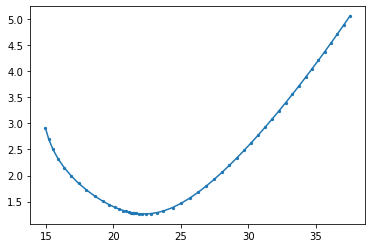

14.969755386904547 37.52755298176332 22.135318518578245 (1.2629997159253568-4.5298552479964875e-09j)
25.83151386072859
1 22.135318518578245 5.28633379209821 0.0


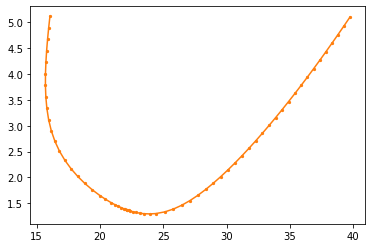

16.048890590564294 39.73728001956942 23.93570712232481 (1.2935152662595604-3.740664688838486e-09j)
73.91302746068686
2 23.93570712232481 5.588410008789536 0.0


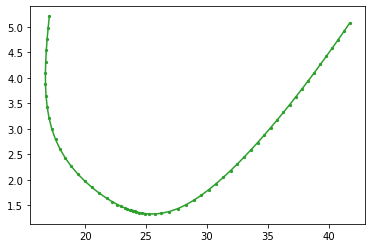

17.05678404435091 41.73779210182026 25.74413900402643 (1.3298838177253949-2.9191972721201157e-09j)
122.36864623893052
3 25.74413900402643 5.890486225480862 0.0


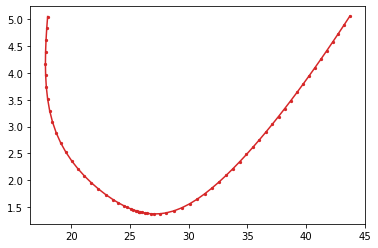

17.976155656590073 43.72211602958991 27.079789788019582 (1.3678042178462362-3.442626112079521e-09j)
177.23365233000368
4 27.079789788019582 6.192562442172188 0.0


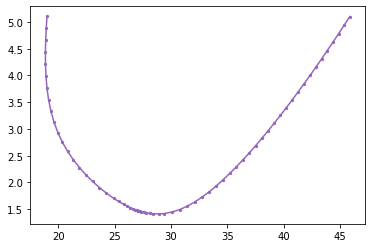

18.9975855846376 45.84632792638167 28.887783822464357 (1.411017127624452-2.8663454443889555e-09j)
233.24390818364918
5 28.887783822464357 6.494638658863514 0.0


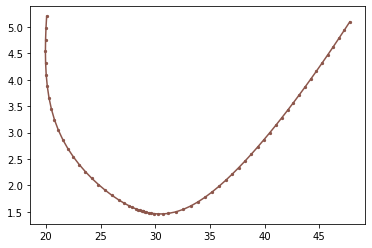

20.04703097583214 47.80315911328755 30.700037343340984 (1.4593119904183012-2.7604011503374658e-09j)
285.84619030263275
6 30.700037343340984 6.796714875554841 0.0


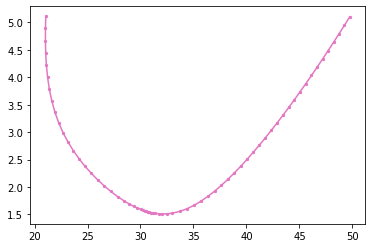

21.065458189038694 49.748761329051824 32.037416878554936 (1.5101407327135834-3.458277645582006e-09j)
338.9444059608504
7 32.037416878554936 7.0987910922461674 0.0


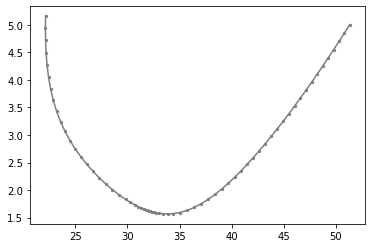

22.14416055451371 51.33590222790153 33.848091943696986 (1.5661470318144008-3.0652061410949102e-09j)
392.92935584671795
8 33.848091943696986 7.400867308937493 0.0


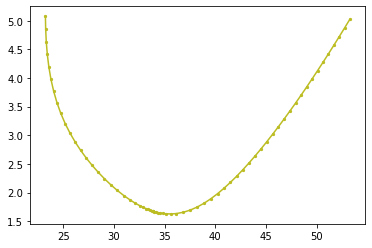

23.246852829900373 53.258832669989815 35.66103184424725 (1.6272977356682656-3.161905644047406e-09j)
456.4219372025691
9 35.66103184424725 7.702943525628819 0.0


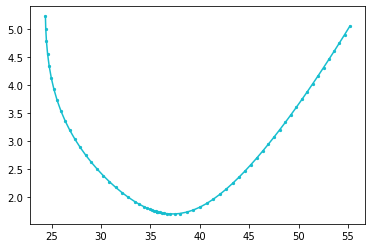

24.37800171095966 55.17613535718365 37.4759673216761 (1.6935763373840673-3.301196866413912e-09j)
524.6312291016802
10 37.4759673216761 7.853981633974483 0.15114994701951814


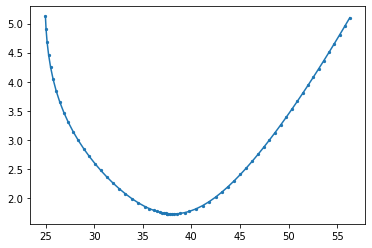

24.981844384304722 56.28901663061514 38.182737098001404 (1.727892845880023-4.147043290594297e-09j)
599.143325207755
11 38.182737098001404 7.853981633974483 0.45344984105855446


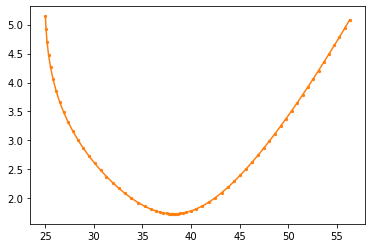

25.023289463645582 56.30967628101865 38.182737098001404 (1.730563062754-4.2987863257815065e-09j)
658.9711064347066
12 38.182737098001404 7.853981633974483 0.7557497350975907


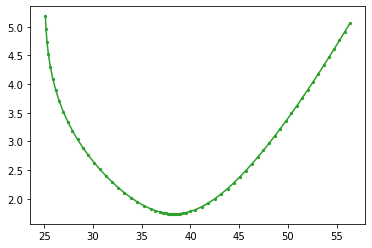

25.10647560660307 56.35306202812515 38.32415858644875 (1.736024694316373-4.30406500910543e-09j)
715.9762206776068
13 38.32415858644875 7.853981633974483 1.058049629136627


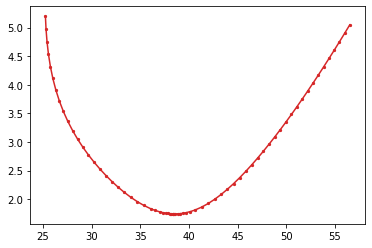

25.23977415252083 56.5226775317265 38.4655724569686 (1.74429096504056-4.360250578827021e-09j)
773.5270124226809
14 38.4655724569686 7.853981633974483 1.3603495231756633


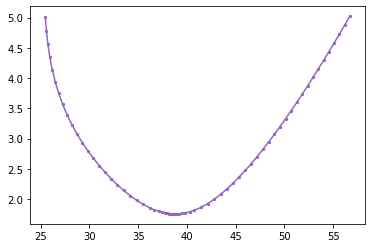

25.47656410491726 56.71294392506669 38.74838271770152 (1.7552695769973272-4.366564395426053e-09j)
831.298882257659
15 38.74838271770152 7.853981633974483 1.6626494172146995


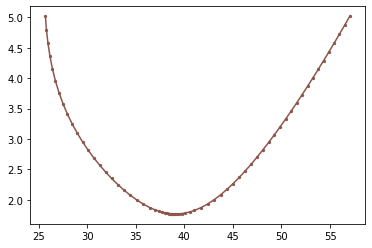

25.706002263490916 57.02876011808112 39.03116983895445 (1.7691838132040663-4.432917425331301e-09j)
886.4088329328224
16 39.03116983895445 7.853981633974483 1.964949311253736


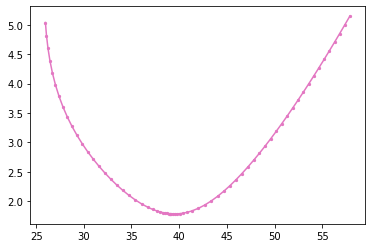

25.97376358122317 57.89366146553832 39.52603674962732 (1.7858029018701815-4.386266017446081e-09j)
941.0117847626098
17 39.52603674962732 7.853981633974483 2.267249205292772


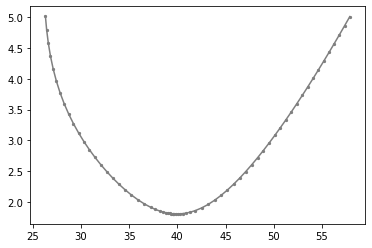

26.308153178300003 57.876982545763525 40.02095652525029 (1.805506108565074-4.420532638381553e-09j)
1000.5972708635963
18 40.02095652525029 7.853981633974482 2.5695490993318084


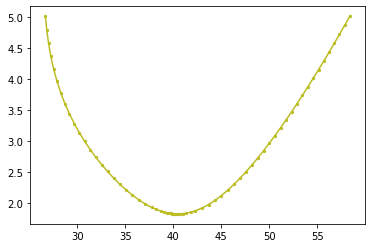

26.682479936278085 58.40826522180894 40.51586489728438 (1.8281243071376725-4.501766549031732e-09j)
1059.3380466187373
19 40.51586489728438 7.853981633974482 2.8718489933708446


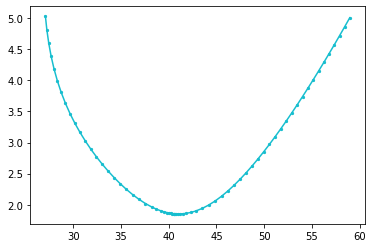

27.094065254242242 58.95670544042745 41.01070223769322 (1.8538292850191638-4.630523469073618e-09j)
1117.9446399486624
20 41.01070223769322 7.853981633974482 3.174148887409881


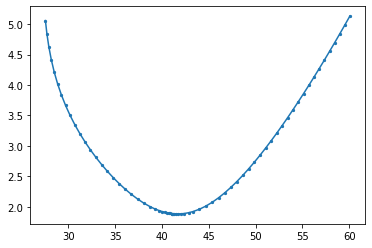

27.540597052316116 60.05696084983061 41.71752992079401 (1.8827315673115528-4.634207919658195e-09j)
1176.6262956177816
21 41.71752992079401 7.853981633974482 3.4764487814489176


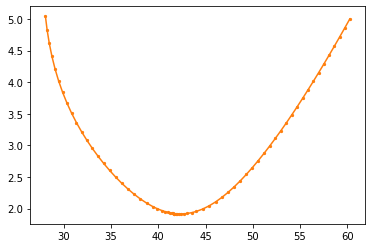

28.06479992193305 60.261714778654564 42.424402031662034 (1.9148928517851855-4.737500459022223e-09j)
1238.835606151726
22 42.424402031662034 7.853981633974482 3.778748675487954


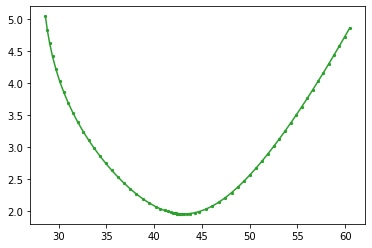

28.627145024774666 60.47510546589434 43.13123114433131 (1.950303638507867-4.888152899760111e-09j)
1299.7962981197052
23 43.13123114433131 7.853981633974482 4.08104856952699


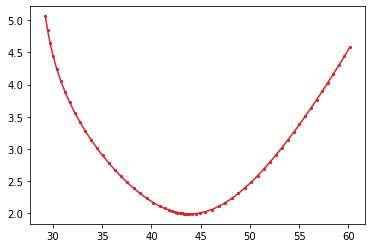

29.223806207574764 60.1448553995219 43.83791605385236 (1.9892018595415355-5.089541236620397e-09j)
1350.9443869497627
24 43.83791605385236 7.853981633974482 4.383348463566026


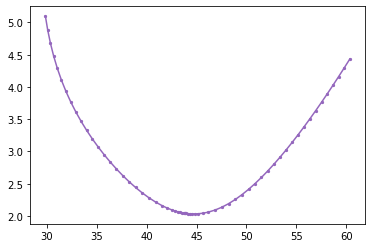

29.852328737504717 60.363516113202856 44.86258399876298 (2.0318415711852547-5.054246778502535e-09j)
1400.5520599549636
25 44.86258399876298 7.592182246175333 4.383348463566026


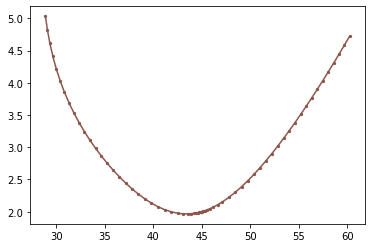

28.86406877761921 60.258042563747196 43.52271891531656 (1.9650486249162116-4.725051306728711e-09j)
1451.3261773339473
26 43.52271891531656 7.330382858376184 4.232198516546508


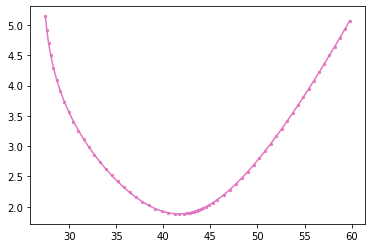

27.46200615033305 59.809583423203755 41.7104545546247 (1.8809762477171952-4.24439084576911e-09j)
1518.8147474899888
27 41.7104545546247 7.068583470577034 4.08104856952699


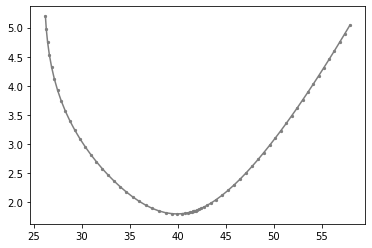

26.18549196658813 57.90566942938086 39.898022109708506 (1.8022768232117516-4.007511407186864e-09j)
1589.3480786406435
28 39.898022109708506 6.8067840827778845 3.929898622507472


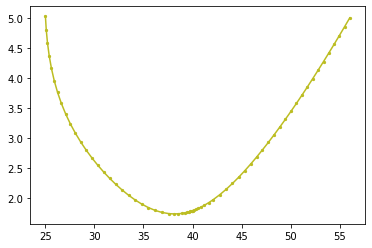

25.02125408616865 55.99801550519258 38.08521144359434 (1.728920950909958-3.820864011820981e-09j)
1666.3689934685826
29 38.08521144359434 6.544984694978735 3.778748675487954


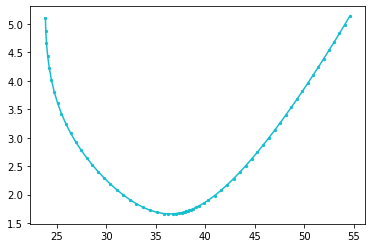

23.83480534272556 54.606281006084345 36.271813215654795 (1.6608995810478226-3.6837464228318607e-09j)
1748.0194159918465
30 36.271813215654795 6.283185307179586 3.6275987284684357


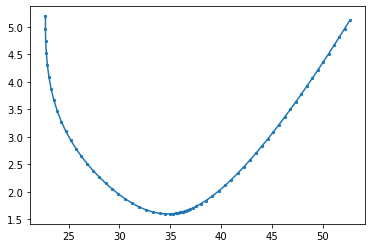

22.712729812215784 52.68239590758922 34.93539321192108 (1.5979257903722233-3.5820853786309525e-09j)
1828.5542380469851
31 34.93539321192108 6.021385919380436 3.4764487814489176


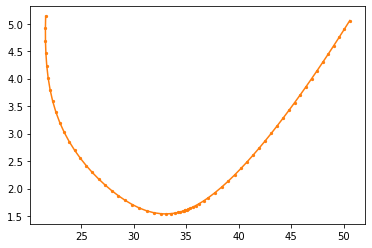

21.62032039344832 50.58957459790408 33.12689335907733 (1.5386399922472462-3.2669550099512517e-09j)
1894.5603208676912
0 52.996079674135984 4.984257575406883 0.0


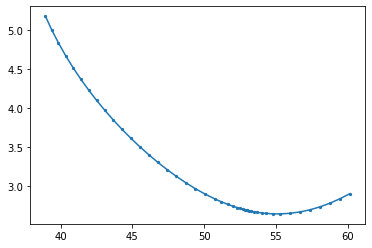

38.9385361628642 60.15605951789082 55.28798933300792 (2.6431281572592566-9.116646013604963e-09j)
1918.9422248518094
1 55.28798933300792 5.28633379209821 0.0


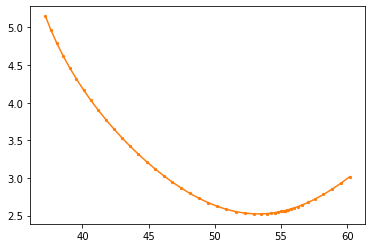

37.19915183989227 60.19763002868254 53.47237065836582 (2.5229717569294676-7.218833835364382e-09j)
1973.3655532025732
2 53.47237065836582 5.588410008789536 0.0


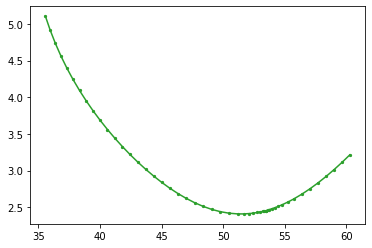

35.56604402596556 60.27570074709016 51.656925274826996 (2.40857918344436-6.546939776284674e-09j)
2026.374660409987
3 51.656925274826996 5.890486225480862 0.0


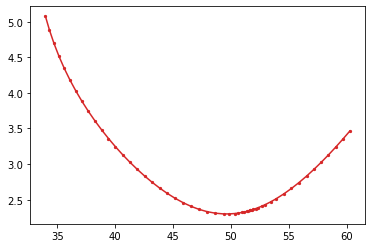

33.97081617441742 60.27601850965195 49.843486009667686 (2.299883618560484-6.0028030832699406e-09j)
2080.27183892671
4 49.843486009667686 6.192562442172188 0.0


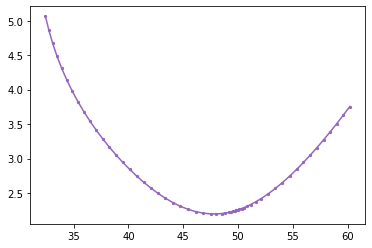

32.419768315970586 60.20662504209352 48.03054627253494 (2.1968055538273497-5.495865308351865e-09j)
2138.228517608717
5 48.03054627253494 6.494638658863514 0.0


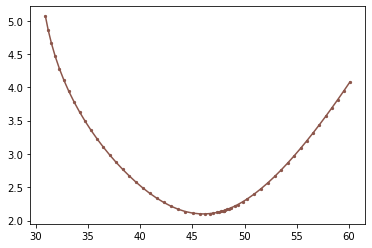

30.919528207315643 60.07591477354108 46.21794914859193 (2.0992757933254826-5.0570767394915875e-09j)
2198.3845068640076
6 46.21794914859193 6.796714875554841 0.0


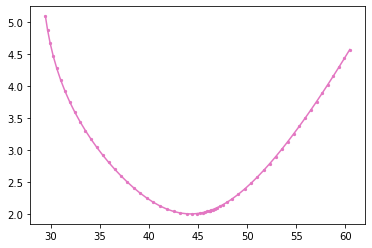

29.477819787935637 60.44425118688918 44.40553241517131 (2.0072307313428635-4.681162275977136e-09j)
2261.742421770934
7 44.40553241517131 7.0987910922461674 0.0


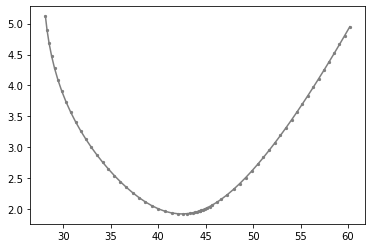

28.100463845415707 60.19284110123357 42.59313007705519 (1.9206138745887944-4.363788445479577e-09j)
2321.941798223648
8 42.59313007705519 7.400867308937493 0.0


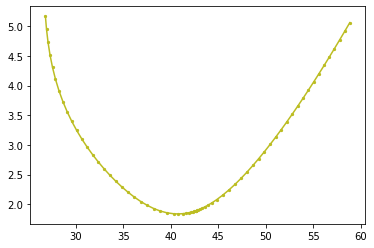

26.791029089247903 58.82920082620557 40.7805651423103 (1.8393779854415984-4.100141340925806e-09j)
2382.1803669389337
9 40.7805651423103 7.702943525628819 0.0


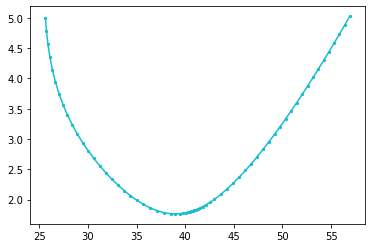

25.616997862240535 56.92356930162328 38.96765032782536 (1.7634883498749807-3.889471583942886e-09j)
2447.03374597989
10 38.96765032782536 7.853981633974483 0.15114994701951814


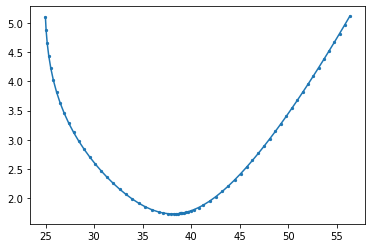

24.987191529182848 56.34512303942389 38.26143344471652 (1.7281384609994117-4.1245229779852504e-09j)
2528.7667804616503
11 38.26143344471652 7.853981633974483 0.45344984105855446


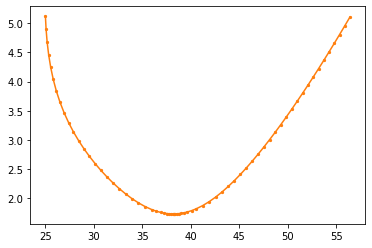

25.02864015890274 56.36802902390423 38.120008630338766 (1.7306389512339202-4.332705296018618e-09j)
2593.1107204048894
12 38.120008630338766 7.853981633974483 0.7557497350975907


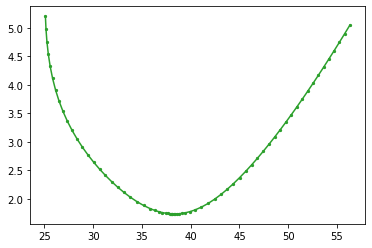

25.102813460262738 56.30644058392302 38.261421404783015 (1.7360828280789957-4.341661828787017e-09j)
2653.2868215357885
13 38.261421404783015 7.853981633974483 1.058049629136627


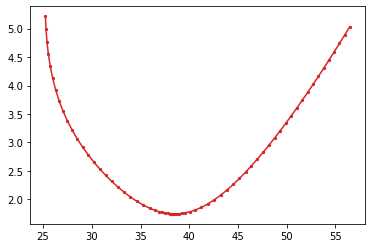

25.235957652062783 56.47597483018438 38.54425519572199 (1.7442519172412092-4.3016158778423735e-09j)
2720.0222724727355
14 38.54425519572199 7.853981633974483 1.3603495231756633


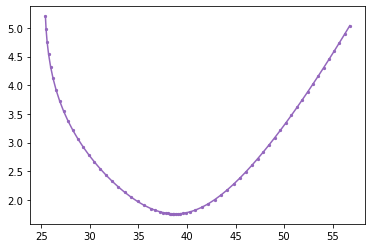

25.41916296892817 56.77162870025297 38.82709476056941 (1.7552777515046702-4.320806827786341e-09j)
2786.5131803345867
15 38.82709476056941 7.853981633974483 1.6626494172146995


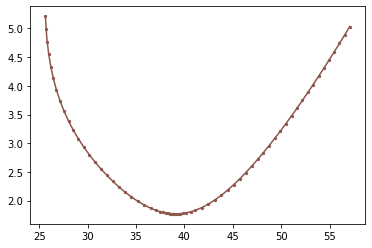

25.643655204060607 57.08759446318608 39.109919964045794 (1.7690835222903343-4.385660626912877e-09j)
2852.694195966702
16 39.109919964045794 7.853981633974483 1.964949311253736


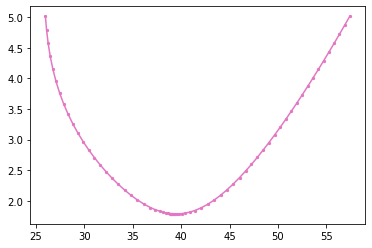

25.98414673392514 57.42299299529966 39.60485269362324 (1.7859526029793826-4.342958132600434e-09j)
2916.0839108750224
17 39.60485269362324 7.853981633974483 2.267249205292772


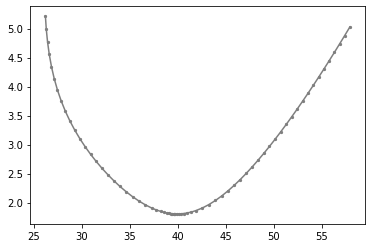

26.230650274628875 57.9361853268686 39.887658987625954 (1.805510677190667-4.531022964211286e-09j)
2981.840381267946
18 39.887658987625954 7.853981633974482 2.5695490993318084


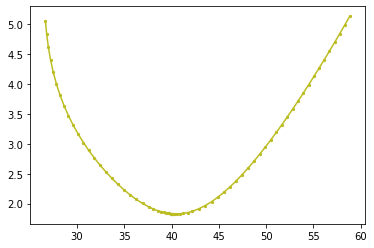

26.661058885635786 58.8403986155937 40.3824194130892 (1.8282004356814894-4.5799737907845944e-09j)
3049.6975802918896
19 40.3824194130892 7.853981633974482 2.8718489933708446


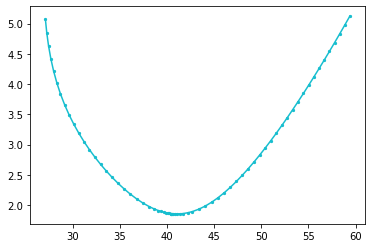

27.070630469157816 59.39009417034047 41.08923945158908 (1.8538512813856842-4.5346140128055474e-09j)
3112.0969055136666
20 41.08923945158908 7.853981633974482 3.174148887409881


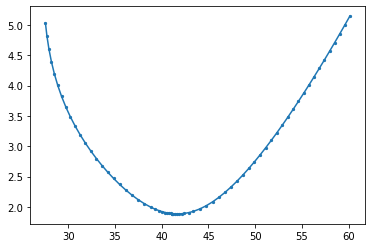

27.555837447002805 60.116276794447025 41.58401462552972 (1.8828031936735496-4.762974897815155e-09j)
3166.384624505881
21 41.58401462552972 7.853981633974482 3.4764487814489176


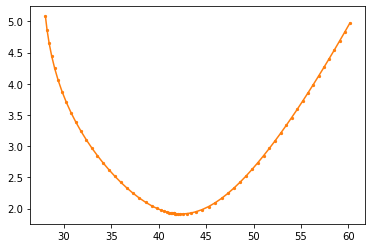

28.036009180498443 60.159934427143654 42.29063057011965 (1.9148807941181487-4.814776558697258e-09j)
3219.9720112318173
22 42.29063057011965 7.853981633974482 3.778748675487954


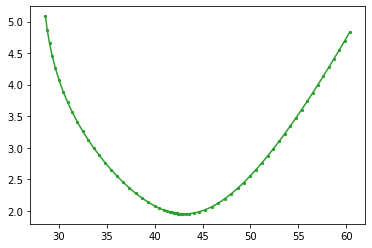

28.594906380268988 60.372221680756816 42.99718924467524 (1.9504101258773512-4.9675438448313996e-09j)
3273.7570136860013
23 42.99718924467524 7.853981633974482 4.08104856952699


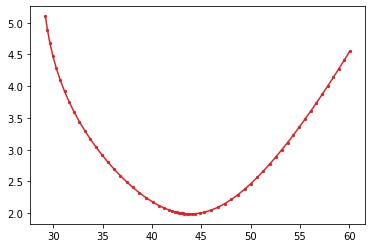

29.188485495239362 60.04015694319684 44.021834982827635 (1.9894306096441163-4.879769749414775e-09j)
3326.027782014571
24 44.021834982827635 7.853981633974482 4.383348463566026


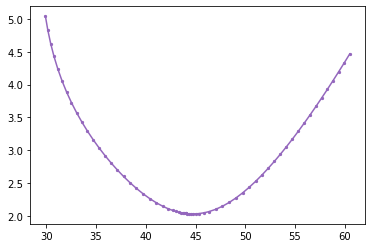

29.907055525307015 60.50843247204778 44.72862503331722 (2.0315919506464453-5.233358679853008e-09j)
3377.7810375806876
25 44.72862503331722 7.592182246175333 4.383348463566026


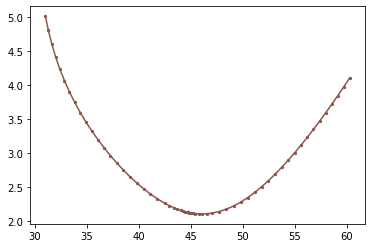

31.02906101746673 60.27353785203231 46.069904224812845 (2.1020584836317693-5.293852285334901e-09j)
3431.3110620137304
26 46.069904224812845 7.330382858376184 4.232198516546508


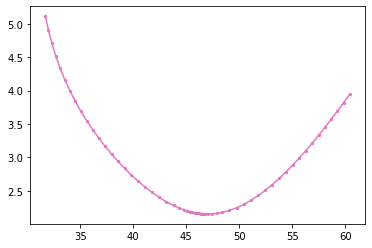

31.705181844177236 60.428920444608956 47.0944242980476 (2.1537825643054256-5.640875999429804e-09j)
3501.5527398008853
27 47.0944242980476 7.068583470577034 4.08104856952699


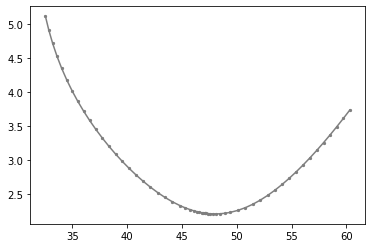

32.55313672538749 60.31450159426207 48.119033750809464 (2.2093862789344323-5.8936611454078e-09j)
3571.215105014853
28 48.119033750809464 6.8067840827778845 3.929898622507472


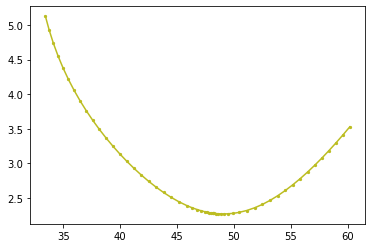

33.43378527200318 60.18110868813353 49.14361624863252 (2.2689115565832045-6.2036950430959205e-09j)
3642.489779725671
29 49.14361624863252 6.544984694978735 3.778748675487954


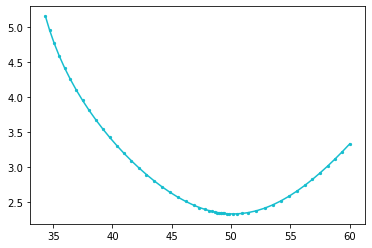

34.34334028662949 60.02324878160795 50.16805900954726 (2.3325354772577205-6.576283741332031e-09j)
3712.4865255476907
30 50.16805900954726 6.283185307179586 3.6275987284684357


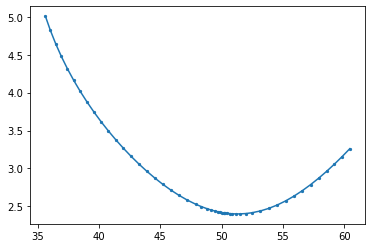

35.64110718439086 60.46063053820425 51.19222872290384 (2.400540397890613-7.016301424682726e-09j)
3786.2220730218105
31 51.19222872290384 6.021385919380436 3.4764487814489176


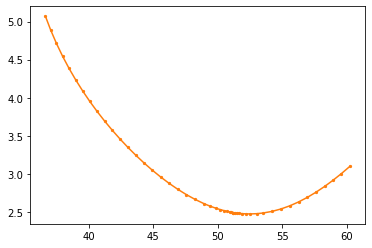

36.61183604281306 60.25212961085512 52.534223702582544 (2.472545937698139-7.183940936847761e-09j)
3851.6336991046555


In [18]:
start=timeit.default_timer()
adssweep=[]
freqsweep=[]
vssweep=[]
wssweep=[]
dirsweep=[]
dssweep=[]
argsdict['verbose']=0
argsdict['lambdamax']=admax

ds=5E-1
ds0=1E-1
argsdict['dsmax']=ds
argsdict['ds']=ds0
argsdict['dsmin']=1E-8

argsdict['epsu']=1E-2
argsdict['epsl']=1E-2
argsdict['dmu_fd']=1E-4
argsdict['epstp']=5E-1
argsdict['epdir']=1E-3
argsdict['thmu']=5E-1
argsdict['thl']=5E0
argsdict['thu']=1E-4

argsdict['itmax']=10
argsdict['Nsteps']=5000

print(ks)
print(len(ks))
load=True
overwrite=True

l=0

for j in range(2):
    ad0=ad0s[j]
    vs0=vn0s[j]
    ws0=wn0s[j]
    freq0=freq0s[j]
    
    argsdict['freq']=freq0
    argsdict['kx']=ks[0][0]
    argsdict['ky']=ks[0][1]
    
    lps,ls,mps,ms,nps,ns=viscid.makeindices(argsdict)
    kappax = (argsdict['kx'] + argsdict['k1x']*ms + argsdict['k2x']*ns)
    kappay = (argsdict['ky'] + argsdict['k1y']*ms + argsdict['k2y']*ns)
    kappa = (kappax**2+kappay**2)**0.5
    kappapx = (argsdict['kx'] + argsdict['k1x']*mps + argsdict['k2x']*nps)
    kappapy = (argsdict['ky'] + argsdict['k1y']*mps + argsdict['k2y']*nps)
    S = (- np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))
    C = (np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))

    #right preconditioner
    shape_flat=((2*argsdict['Nx']+1)*(2*argsdict['Ny']+1),(2*argsdict['Nx']+1)*(2*argsdict['Ny']+1))
    shape2=((2*argsdict['Nx']+1),(2*argsdict['Ny']+1),(2*argsdict['Nx']+1),(2*argsdict['Ny']+1))
    A2=argsdict['g']*(argsdict['rho']**2*(kappax*kappapx+kappay*kappapy)/kappa*C)
    argsdict['preconditioner']=np.linalg.pinv(A2.reshape(shape_flat)).reshape(shape2)

    argsdict['precondition_axes']=((6,7),(0,1))
    argsdict['precondition_order']=(0,1,2,3,4,5,6,7)

    for i in range(len(ks)):
        kx=ks[i][0]
        ky=ks[i][1]
        print(i,freq0,kx,ky)
        if not os.path.exists('data/experiment/%iads_flat.npy'%(l)) or not load:
            argsdict['freq']=freq0
            if(argsdict['kx']!=kx):
                argsdict['par']='kx'
                argsdict['pari']=np.min([kx,argsdict['kx']])
                argsdict['parf']=np.max([kx,argsdict['kx']])

                argsdict['ds']=np.sign(kx-argsdict['kx'])*1E-4
                ads1,vs1,ws1,pars1,dirs1,dss1=viscid.pseudocont(ad0, vs0, ws0, mat, argsdict, mat2)
                argsdict['kx']=kx
                ads1,vs1,ws1=viscid.rayleigh_mat(ads1[-1], vs1[-1], ws1[-1], mat, argsdict, mat2)
                ad0=ads1[-1]
                vs0=vs1[-1]
                ws0=ws1[-1]
            if(argsdict['ky']!=ky):
                argsdict['par']='ky'
                argsdict['pari']=np.min([ky,argsdict['ky']])
                argsdict['parf']=np.max([ky,argsdict['ky']])

                argsdict['ds']=np.sign(ky-argsdict['ky'])*1E-4
                ads1,vs1,ws1,pars1,dirs1,dss1=viscid.pseudocont(ad0, vs0, ws0, mat, argsdict, mat2)
                argsdict['ky']=ky
                ads1,vs1,ws1=viscid.rayleigh_mat(ads1[-1], vs1[-1], ws1[-1], mat, argsdict, mat2)
                ad0=ads1[-1]
                vs0=vs1[-1]
                ws0=ws1[-1]

            lps,ls,mps,ms,nps,ns=viscid.makeindices(argsdict)
            kappax = (argsdict['kx'] + argsdict['k1x']*ms + argsdict['k2x']*ns)
            kappay = (argsdict['ky'] + argsdict['k1y']*ms + argsdict['k2y']*ns)
            kappa = (kappax**2+kappay**2)**0.5
            kappapx = (argsdict['kx'] + argsdict['k1x']*mps + argsdict['k2x']*nps)
            kappapy = (argsdict['ky'] + argsdict['k1y']*mps + argsdict['k2y']*nps)
            S = (- np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))
            C = (np.exp(-kappa*argsdict['h0']) * iv(ms-mps, kappa*argsdict['As']*0.5) * iv(ns-nps, kappa*argsdict['As']*0.5) + np.exp(kappa*argsdict['h0']) * iv(ms-mps, -kappa*argsdict['As']*0.5) * iv(ns-nps, -kappa*argsdict['As']*0.5))

            #right preconditioner
            shape_flat=((2*argsdict['Nx']+1)*(2*argsdict['Ny']+1),(2*argsdict['Nx']+1)*(2*argsdict['Ny']+1))
            shape2=((2*argsdict['Nx']+1),(2*argsdict['Ny']+1),(2*argsdict['Nx']+1),(2*argsdict['Ny']+1))
            A2=argsdict['g']*(argsdict['rho']**2*(kappax*kappapx+kappay*kappapy)/kappa*C)
            argsdict['preconditioner']=np.linalg.pinv(A2.reshape(shape_flat)).reshape(shape2)

            argsdict['precondition_axes']=((6,7),(0,1))
            argsdict['precondition_order']=(0,1,2,3,4,5,6,7)

            argsdict['freq']=freq0
            argsdict['par']='freq'
            argsdict['pari']=minfreq
            argsdict['parf']=maxfreq

            argsdict['ds']=ds0
            ads2,vs2,ws2,pars2,dirs2,dss2=viscid.pseudocont(ad0, vs0, ws0, mat, argsdict, mat2, real=1)
            argsdict['freq']=freq0        
            argsdict['ds']=-ds0
            ads3,vs3,ws3,pars3,dirs3,dss3=viscid.pseudocont(ad0, vs0, ws0, mat, argsdict, mat2, real=1) 
            

            freqsweep=freqsweep+[np.flip(pars3).tolist()+pars2]
            adssweep=adssweep+[np.flip(ads3).tolist()+ads2]
            vssweep=vssweep+[np.flip(vs3,axis=0).tolist()+vs2]
            wssweep=wssweep+[np.flip(ws3,axis=0).tolist()+ws2]
            dirsweep=dirsweep+[np.flip(dirs3,axis=0).tolist()+dirs2]
            dssweep=dssweep+[np.flip(dss3,axis=0).tolist()+dss2]
            if overwrite:
                np.save('data/experiment/%iads_flat.npy'%(l),adssweep[l])
                np.save('data/experiment/%ivs_flat.npy'%(l),vssweep[l])
                np.save('data/experiment/%iws_flat.npy'%(l),wssweep[l])
                np.save('data/experiment/%ifreqs_flat.npy'%(l),freqsweep[l])
                np.save('data/experiment/%idirs_flat.npy'%(l),dirsweep[l])
                np.save('data/experiment/%idss_flat.npy'%(l),dssweep[l])

        else:
            adssweep=adssweep+[np.load('data/experiment/%iads_flat.npy'%(l))]
            freqsweep=freqsweep+[np.load('data/experiment/%ifreqs_flat.npy'%(l))]
            argsdict['kx']=kx
            argsdict['ky']=ky

        plt.plot(freqsweep[l],np.abs(np.real(adssweep[l])),c=colors[i%len(colors)])
        plt.scatter(freqsweep[l],np.abs(np.real(adssweep[l])),c=colors[i%len(colors)],s=5)
        plt.show() 
            
        peaks,pprop=find_peaks(-np.abs(adssweep[-1]))
        ind=peaks[np.argmin(np.abs(np.array(freqsweep[-1])[peaks]-freq0))]
        ad0=adssweep[-1][ind]
        if vssweep != []:
            vs0=np.array(vssweep[-1][ind])
            ws0=np.array(wssweep[-1][ind])
        freq0=freqsweep[-1][ind]
        print(freqsweep[-1][0],freqsweep[-1][-1],freq0,ad0)
        
        l=l+1

        stop=timeit.default_timer()
        print(stop-start)

### Plot theoreical results against experimental results

In [19]:
adssweep=[np.load('data/experiment/%iads.npy'%(i)) for i in range(2*len(ks))]
freqsweep=[np.load('data/experiment/%ifreqs.npy'%(i)) for i in range(2*len(ks))]

adssweep2=[np.load('data/experiment/%iads_flat.npy'%(i)) for i in range(2*len(ks))]
freqsweep2=[np.load('data/experiment/%ifreqs_flat.npy'%(i)) for i in range(2*len(ks))]

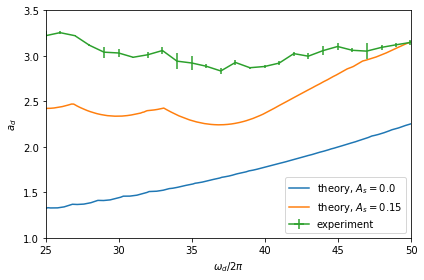

In [23]:
plotfreqs=20+(50-20)*np.arange(1000)/1000
acs=[]
for i in range(2*len(ks)):
    f=interp1d(np.array(freqsweep2[i]),np.real(adssweep2[i]))
    inds=np.intersect1d(np.where(plotfreqs<np.max(freqsweep2[i]))[0],np.where(plotfreqs>np.min(freqsweep2[i]))[0])
    ac=np.ones(len(plotfreqs))*np.inf
    ac[inds]=f(plotfreqs[inds])
    acs=acs+[ac]
plt.plot(plotfreqs,np.min(np.array(acs),axis=0),label='theory, $A_s=0.0$')

acs=[]
for i in range(2*len(ks)):
    f=interp1d(np.array(freqsweep[i]),np.real(adssweep[i]))
    inds=np.intersect1d(np.where(plotfreqs<np.max(freqsweep[i]))[0],np.where(plotfreqs>np.min(freqsweep[i]))[0])
    ac=np.ones(len(plotfreqs))*np.inf
    ac[inds]=f(plotfreqs[inds])
    acs=acs+[ac]
plt.plot(plotfreqs,np.min(np.array(acs),axis=0),label='theory, $A_s=0.15$')

plt.xlabel(r'$\omega_d/2\pi$')
plt.ylabel(r'$a_d$')
plt.ylim(0,20.0)
plt.tight_layout()
filebases=['data/experiment/new_20_50/new_20_50','data/experiment/new_20_50_2/new_20_50_2','data/experiment/new_20_50_3/new_20_50_3']
dats=[]
for filebase in filebases:
    dat=np.loadtxt('%s.txt'%(filebase))
    order=np.argsort(dat[:,2])
    dats=dats+[dat[order]]
x,y=np.mean(np.array(dats)[:,:,[2,1]],axis=0).T
xerr,yerr=np.std(np.array(dats)[:,:,[2,1]],axis=0).T
plt.errorbar(x,y,xerr=xerr,yerr=yerr,label='experiment')
plt.xlabel(r'$\omega_d/2\pi$')
plt.ylabel(r'$a_d$')
plt.xlim(25,50)
plt.ylim(1,3.5)
plt.tight_layout()
plt.legend()
plt.savefig('plots/experiment_boundary.pdf')
plt.show()